In [60]:
import os, glob, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch

RESULTS_DIR   = '/workspace/PCFG/results'
HISTORIES_DIR = f'{RESULTS_DIR}/histories'

from config import CFG
mcfg = CFG['model']
N_LAYERS = mcfg['n_layer']

CORRS = [0.0,0.25, 0.5, 0.75, 1.0]#CFG['experiment']['correlation_values']
CONCS = CFG['experiment']['concentration_values']

# Seeds to load and average over
SEEDS = [124]

print('Correlations:', CORRS)
print('Concentrations:', CONCS)
print('Seeds:', SEEDS)

# --- Colour / alpha helpers (shared by loss curves and metric plots) ---

CORR_PALETTE = {
    0.00: '#e74c3c',   # red
    0.25: '#e67e22',   # orange
    0.50: '#f1c40f',   # yellow
    0.75: '#2ecc71',   # green
    1.00: '#2980b9',   # blue
}

CONC_ALPHA = {c: 0.25 + 0.75 * (c - min(CONCS)) / (max(CONCS) - min(CONCS))
              for c in CONCS}

VAL_SPLITS = ['count_a_corr', 'count_a_uncorr', 'count_b_corr', 'count_b_uncorr',
              'all_other_corr', 'all_other_uncorr']
SPLIT_LABELS = {
    'count_a_corr':     'Count-A (correlated)',
    'count_a_uncorr':   'Count-A (uncorrelated)',
    'count_b_corr':     'Count-B (correlated)',
    'count_b_uncorr':   'Count-B (uncorrelated)',
    'all_other_corr':   'All other (correlated)',
    'all_other_uncorr': 'All other (uncorrelated)',
}

WEIGHTED_SPLITS = {
    'count_a_avg':   ('count_a_corr',   'count_a_uncorr'),
    'count_b_avg':   ('count_b_corr',   'count_b_uncorr'),
    'all_other_avg': ('all_other_corr', 'all_other_uncorr'),
}

def _get_vals(hist, split, metric, corr, use_weighted):
    """Get values from history, optionally using corr-weighted average."""
    if use_weighted and split in WEIGHTED_SPLITS:
        corr_split, uncorr_split = WEIGHTED_SPLITS[split]
        if corr_split in hist['val']:
            return corr * np.array(hist['val'][corr_split][metric]) + \
                   (1 - corr) * np.array(hist['val'][uncorr_split][metric])
        if split in hist['val']:
            return np.array(hist['val'][split][metric])
        return None
    if split in hist['val']:
        return np.array(hist['val'][split][metric])
    return None

Correlations: [0.0, 0.25, 0.5, 0.75, 1.0]
Concentrations: [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 1.0]
Seeds: [124]


## Load histories

In [61]:
def _avg_histories(hist_list):
    """Recursively average a list of history dicts (same structure, same keys).
    Lists of numbers are element-wise averaged; 'steps' is taken from the first."""
    if not hist_list:
        return {}
    first = hist_list[0]
    if isinstance(first, dict):
        out = {}
        for k in first:
            children = [h[k] for h in hist_list if k in h]
            if not children:
                continue
            out[k] = _avg_histories(children)
        return out
    if isinstance(first, list):
        # Average element-wise across seeds
        try:
            arrs = [np.array(h, dtype=float) for h in hist_list]
            return np.mean(arrs, axis=0).tolist()
        except (ValueError, TypeError):
            return first  # non-numeric list, just keep first
    return first  # scalar / non-mergeable

# Load all seeds, group by canonical name, then average
_per_seed = {}  # canonical_name -> [hist, hist, ...]
for seed in SEEDS:
    for path in sorted(glob.glob(f'{HISTORIES_DIR}/*_seed{seed}_history.pth')):
        fname = os.path.basename(path).replace('_history.pth', '')
        canonical = fname.replace(f'_seed{seed}', '')
        h = torch.load(path, map_location='cpu', weights_only=False)
        _per_seed.setdefault(canonical, []).append(h)

histories = {}
for name, hlist in _per_seed.items():
    histories[name] = _avg_histories(hlist) if len(hlist) > 1 else hlist[0]

print(f'Loaded {sum(len(v) for v in _per_seed.values())} history files across {len(SEEDS)} seed(s)')
print(f'Averaged into {len(histories)} canonical histories')

# Check which histories have gradient metrics
has_metrics = [k for k in histories if 'grad_count_a_vs_count_b' in histories[k]]
has_drift = [k for k in histories if 'layerwise_drift' in histories[k]]
print(f'Histories with gradient metrics: {len(has_metrics)}')
print(f'Histories with drift metrics: {len(has_drift)}')
if has_metrics:
    print(f'Sample keys: {list(histories[has_metrics[0]].keys())}')

Loaded 40 history files across 1 seed(s)
Averaged into 40 canonical histories
Histories with gradient metrics: 40
Histories with drift metrics: 40
Sample keys: ['steps', 'val', 'train_loss', 'train_answer_acc', 'grad_count_a_vs_count_b', 'grad_count_a_vs_all_other', 'layerwise_drift']


## Loss & accuracy curves

Colour = correlation, alpha = concentration (darker = more concentrated).  
Weighted-average panels combine correlated/uncorrelated splits using the training correlation.

In [62]:
def plot_loss_curves(phase='finetune', metric='loss', figsize=(18, 9), use_weighted=False):
    """Plot all runs for a given training phase.
    phase        : 'finetune' or 'reverse'
    metric       : 'loss' or 'answer_acc'
    use_weighted : if True, show 3 weighted-avg panels instead of raw splits
    """
    splits = list(WEIGHTED_SPLITS.keys()) if use_weighted else VAL_SPLITS
    labels = {k: k.replace('_', ' ').title() for k in splits}
    if not use_weighted:
        labels = SPLIT_LABELS

    fig, axes = plt.subplots(1, len(splits), figsize=figsize, sharey=False)
    if len(splits) == 1:
        axes = [axes]
    wt_tag = ' (corr-weighted avg)' if use_weighted else ''
    fig.suptitle(f'{phase.capitalize()} phase — validation {metric}{wt_tag}',
                 fontsize=14, fontweight='bold')

    for ax, split in zip(axes, splits):
        for corr in CORRS:
            color = CORR_PALETTE[corr]
            for conc in CONCS:
                key = f'{phase}_corr_{corr:.2f}_conc_{conc:.2f}'
                if key not in histories:
                    continue
                h = histories[key]
                vals = _get_vals(h, split, metric, corr, use_weighted)
                if vals is None:
                    continue
                steps = h['steps']
                ax.plot(steps, vals,
                        color=color,
                        alpha=CONC_ALPHA[conc],
                        linewidth=1.5,
                        label=f'corr={corr:.2f} conc={conc:.2f}')

        ax.set_title(labels.get(split, split), fontsize=11)
        ax.set_xlabel('Step')
        ax.set_ylabel(metric.replace('_', ' ').capitalize())
        ax.grid(True, alpha=0.3)

    corr_handles = [
        plt.Line2D([0], [0], color=CORR_PALETTE[c], linewidth=2,
                   label=f'corr = {c:.2f}')
        for c in CORRS
    ]
    conc_handles = [
        plt.Line2D([0], [0], color='grey', alpha=CONC_ALPHA[c], linewidth=2,
                   label=f'conc = {c:.2f}')
        for c in CONCS
    ]
    fig.legend(handles=corr_handles + conc_handles,
               loc='lower center', ncol=len(CORRS) + len(CONCS),
               fontsize=8, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    plt.show()


def plot_combined_loss_curves(metric='loss', figsize=(18, 9), use_weighted=False):
    """Plot finetune + reverse phases appended, with a vertical line at the boundary."""
    splits = list(WEIGHTED_SPLITS.keys()) if use_weighted else VAL_SPLITS
    labels = {k: k.replace('_', ' ').title() for k in splits}
    if not use_weighted:
        labels = SPLIT_LABELS

    fig, axes = plt.subplots(1, len(splits), figsize=figsize, sharey=False)
    if len(splits) == 1:
        axes = [axes]
    wt_tag = ' (corr-weighted avg)' if use_weighted else ''
    fig.suptitle(f'Finetune → Reverse — validation {metric}{wt_tag}',
                 fontsize=14, fontweight='bold')

    boundary_step = None

    for ax, split in zip(axes, splits):
        for corr in CORRS:
            color = CORR_PALETTE[corr]
            for conc in CONCS:
                ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
                rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'
                if ft_key not in histories or rv_key not in histories:
                    continue

                ft_h = histories[ft_key]
                rv_h = histories[rv_key]

                ft_vals = _get_vals(ft_h, split, metric, corr, use_weighted)
                rv_vals = _get_vals(rv_h, split, metric, corr, use_weighted)
                if ft_vals is None or rv_vals is None:
                    continue

                ft_steps = ft_h['steps']
                ft_last = ft_steps[-1]
                rv_steps = [ft_last + s for s in rv_h['steps']]

                combined_steps = list(ft_steps) + list(rv_steps)
                combined_vals  = list(ft_vals)  + list(rv_vals)

                if boundary_step is None:
                    boundary_step = ft_last

                ax.plot(combined_steps, combined_vals,
                        color=color,
                        alpha=CONC_ALPHA[conc],
                        linewidth=1.5)

        if boundary_step is not None:
            ax.axvline(boundary_step, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_title(labels.get(split, split), fontsize=11)
        ax.set_xlabel('Step')
        ax.set_ylabel(metric.replace('_', ' ').capitalize())
        ax.grid(True, alpha=0.3)

    corr_handles = [
        plt.Line2D([0], [0], color=CORR_PALETTE[c], linewidth=2,
                   label=f'corr = {c:.2f}')
        for c in CORRS
    ]
    conc_handles = [
        plt.Line2D([0], [0], color='grey', alpha=CONC_ALPHA[c], linewidth=2,
                   label=f'conc = {c:.2f}')
        for c in CONCS
    ]
    phase_handle = [plt.Line2D([0], [0], color='black', linestyle='--',
                               alpha=0.5, linewidth=1, label='finetune → reverse')]

    fig.legend(handles=corr_handles + conc_handles + phase_handle,
               loc='lower center', ncol=len(CORRS) + len(CONCS) + 1,
               fontsize=8, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    plt.show()

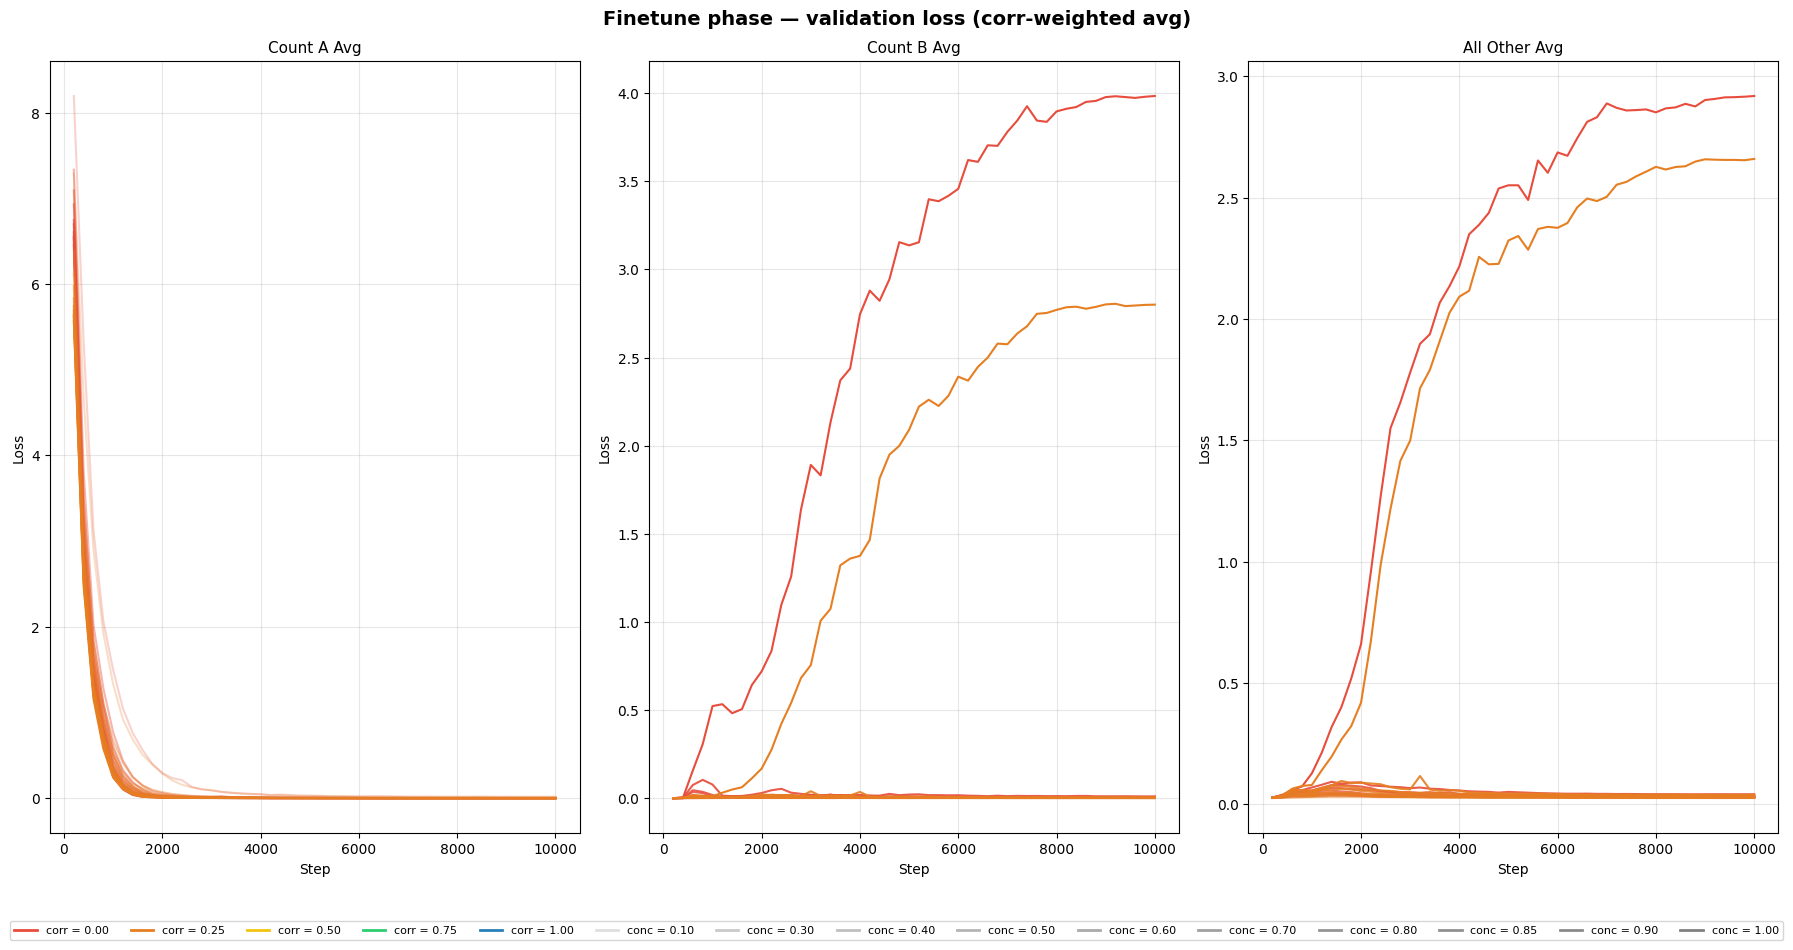

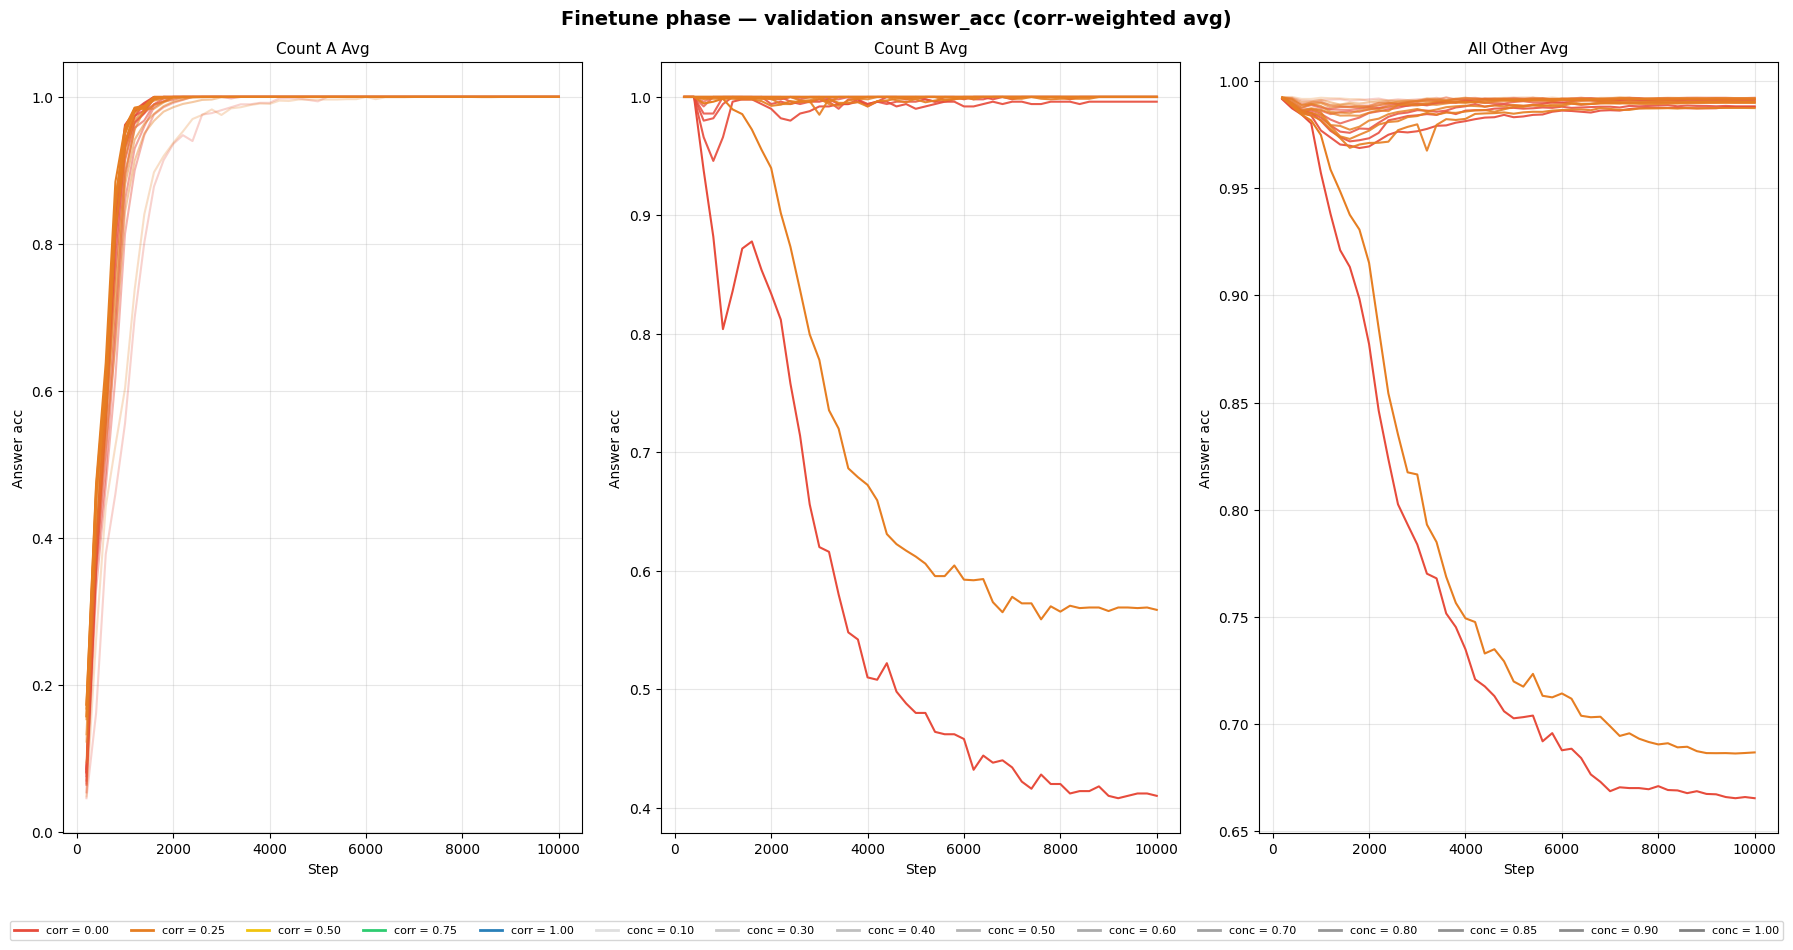

In [63]:
plot_loss_curves(phase='finetune', metric='loss', use_weighted=True)
plot_loss_curves(phase='finetune', metric='answer_acc', use_weighted=True)

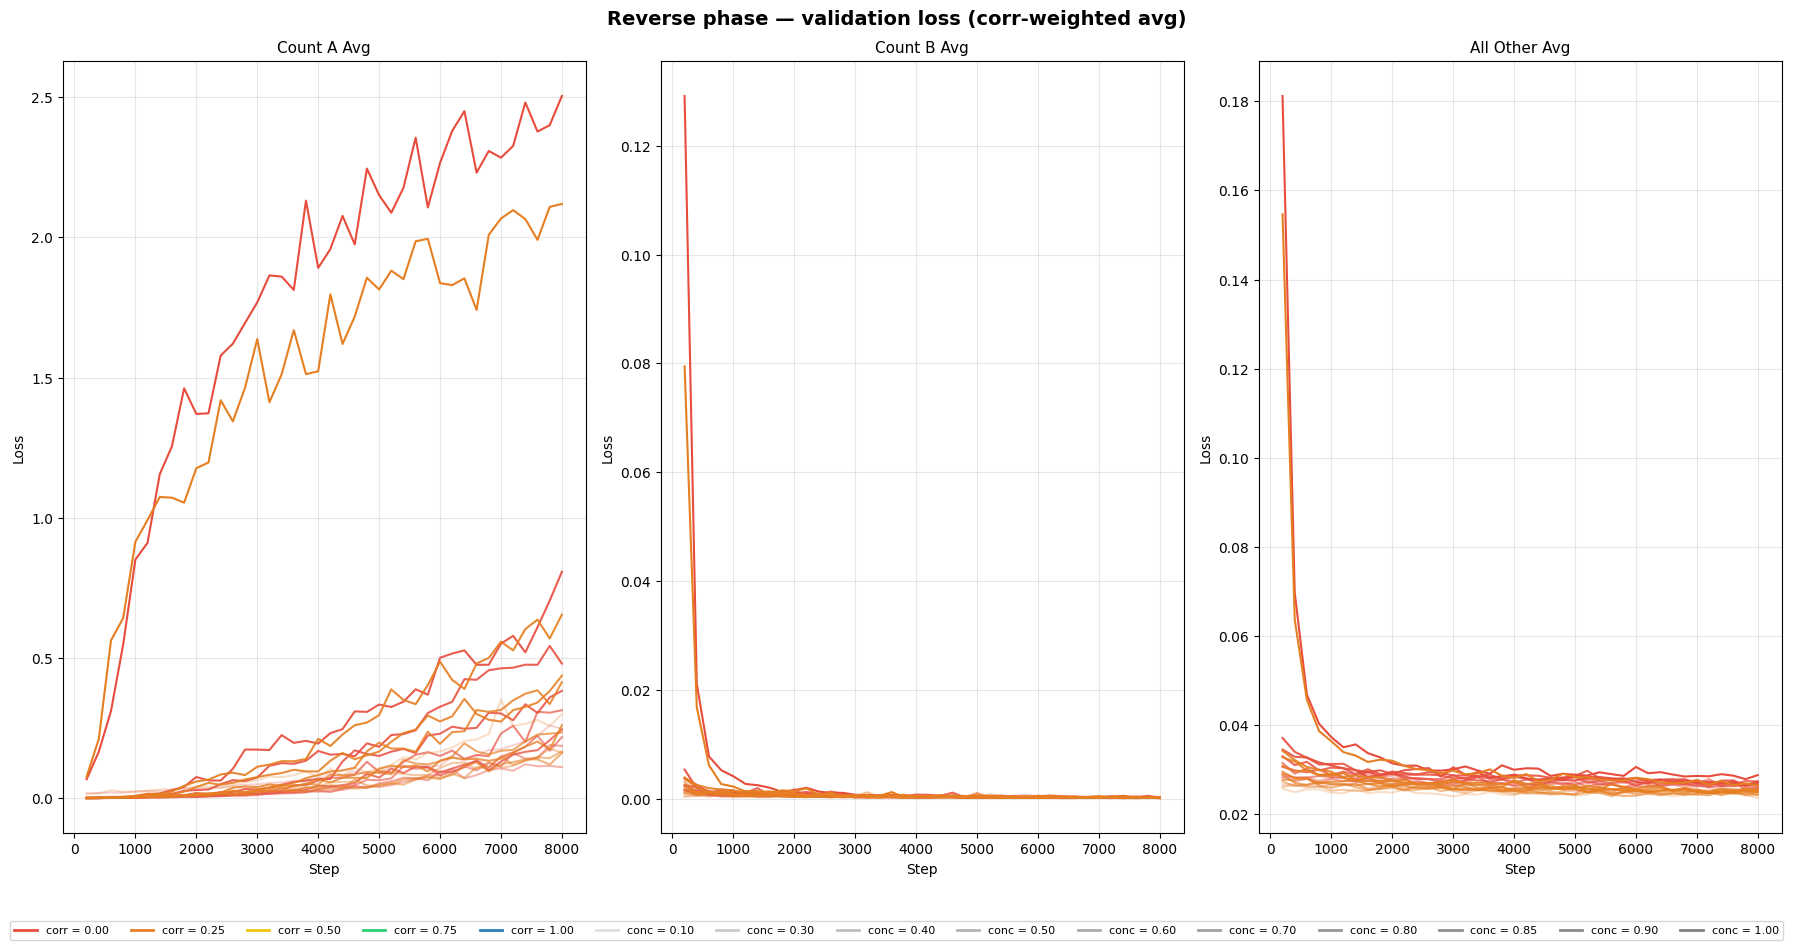

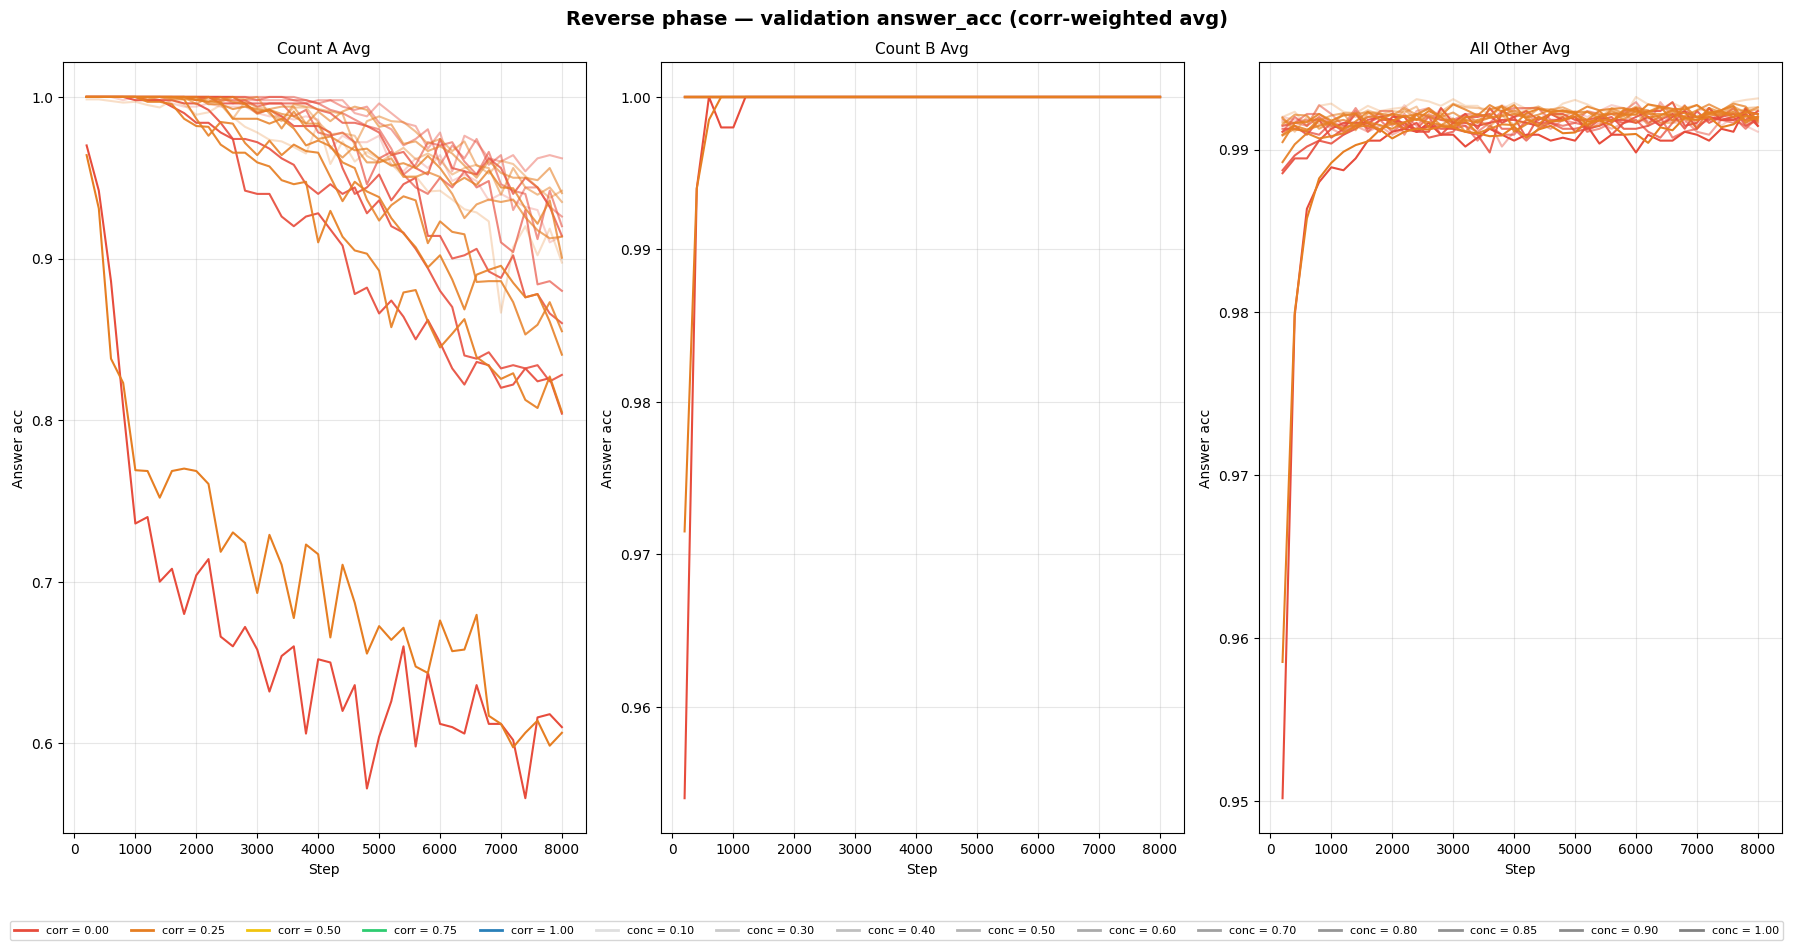

In [64]:
plot_loss_curves(phase='reverse', metric='loss', use_weighted=True)
plot_loss_curves(phase='reverse', metric='answer_acc', use_weighted=True)

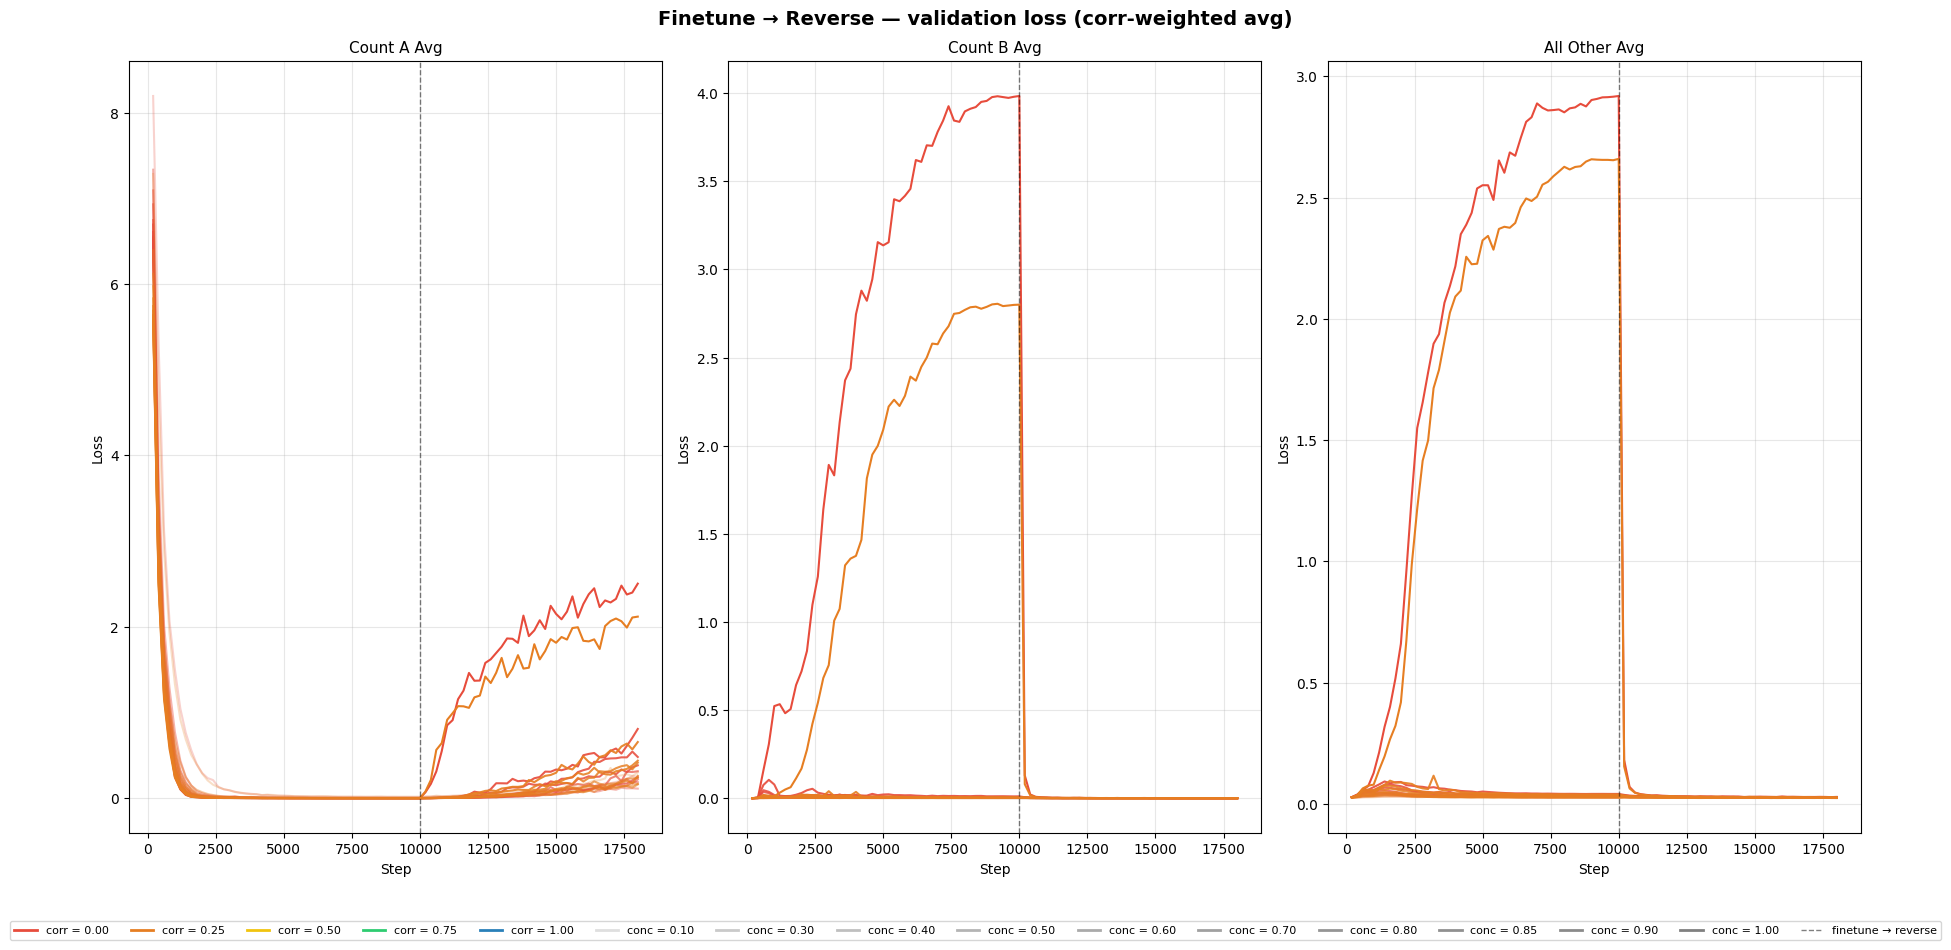

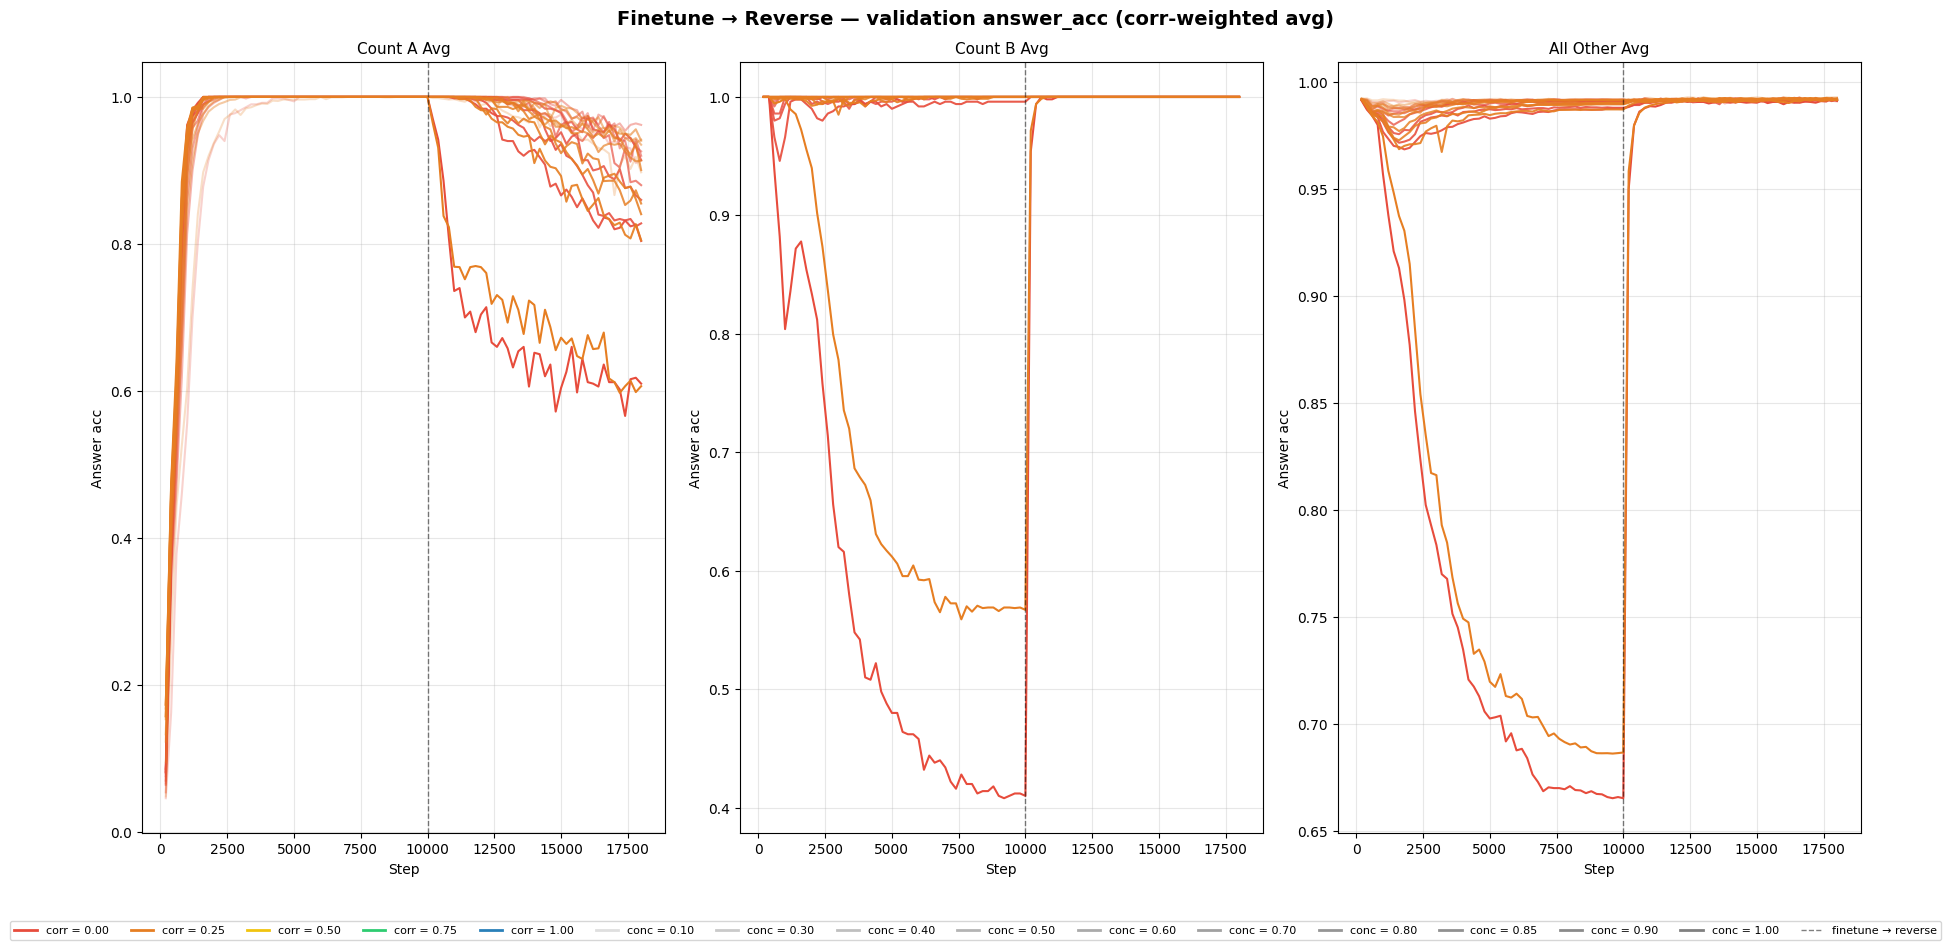

In [65]:
plot_combined_loss_curves(metric='loss', use_weighted=True)
plot_combined_loss_curves(metric='answer_acc', use_weighted=True)

## Final-step summary heatmaps (correlation × concentration)

Each cell shows the metric value at the **last eval step** of that phase.
Rows = correlation, columns = concentration.

In [66]:
def _final_val(hist, split, metric, corr, use_weighted=True):
    """Return the last recorded value for a (split, metric) pair."""
    vals = _get_vals(hist, split, metric, corr, use_weighted)
    if vals is None or len(vals) == 0:
        return np.nan
    return vals[-1]


def build_final_grid(phase, split, metric, use_weighted=True):
    """Build a (len(CORRS), len(CONCS)) array of final metric values."""
    grid = np.full((len(CORRS), len(CONCS)), np.nan)
    for i, corr in enumerate(CORRS):
        for j, conc in enumerate(CONCS):
            key = f'{phase}_corr_{corr:.2f}_conc_{conc:.2f}'
            if key not in histories:
                continue
            grid[i, j] = _final_val(histories[key], split, metric, corr, use_weighted)
    return grid


def plot_summary_heatmaps(phase, specs, suptitle, figsize=None, fmt='.3f'):
    """
    specs: list of (split, metric, title, cmap, use_weighted) tuples.
    """
    n = len(specs)
    if figsize is None:
        figsize = (5.5 * n, 0.9 * len(CORRS) + 2)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    fig.suptitle(suptitle, fontsize=14, fontweight='bold')

    for ax, (split, metric, title, cmap, use_weighted) in zip(axes, specs):
        grid = build_final_grid(phase, split, metric, use_weighted)
        im = ax.imshow(grid, aspect='auto', cmap=cmap, interpolation='nearest')
        # Annotate cells
        for i in range(len(CORRS)):
            for j in range(len(CONCS)):
                v = grid[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:{fmt}}', ha='center', va='center', fontsize=7,
                            color='white' if v < (grid[~np.isnan(grid)].mean()) else 'black')
        ax.set_xticks(range(len(CONCS)))
        ax.set_xticklabels([f'{c:.2f}' for c in CONCS], fontsize=7, rotation=45)
        ax.set_yticks(range(len(CORRS)))
        ax.set_yticklabels([f'{c:.2f}' for c in CORRS], fontsize=8)
        ax.set_xlabel('Concentration')
        if ax is axes[0]:
            ax.set_ylabel('Correlation')
        ax.set_title(title, fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.8, pad=0.04)

    plt.tight_layout()
    plt.show()

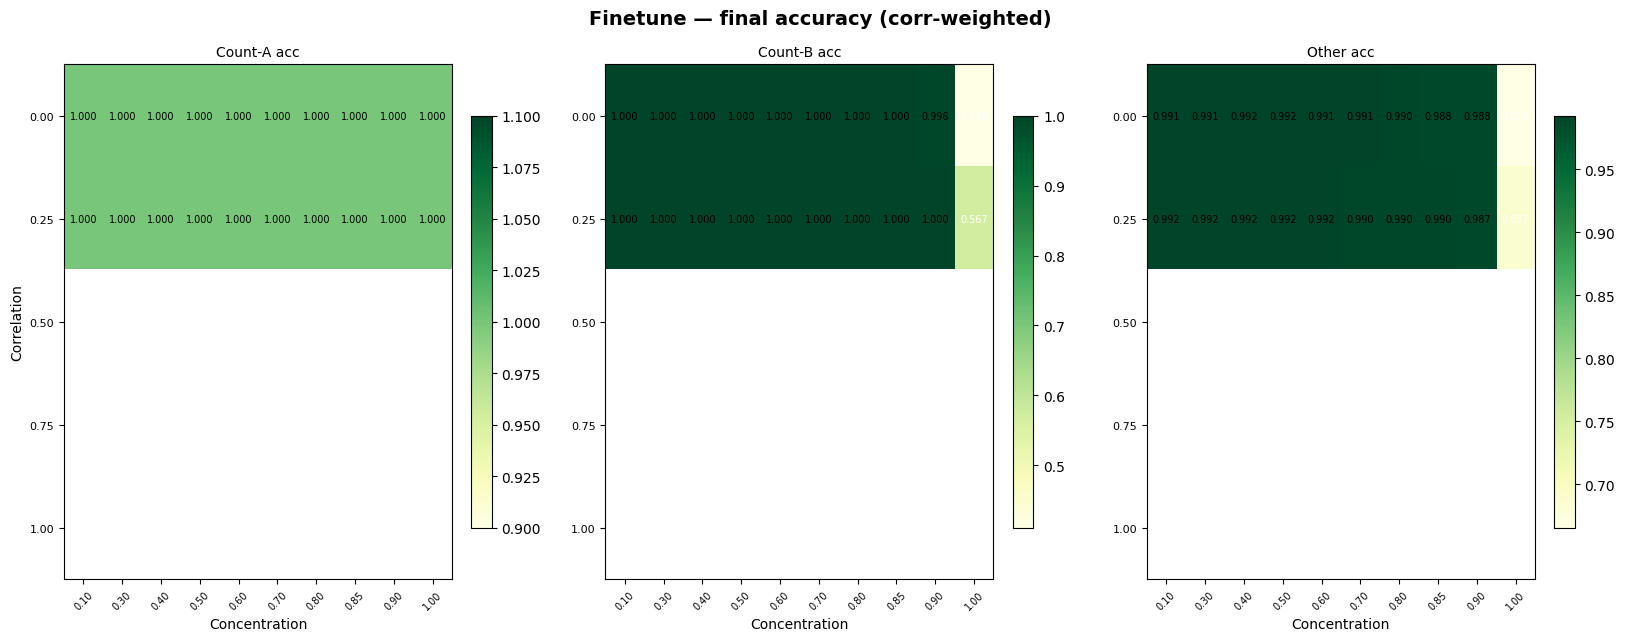

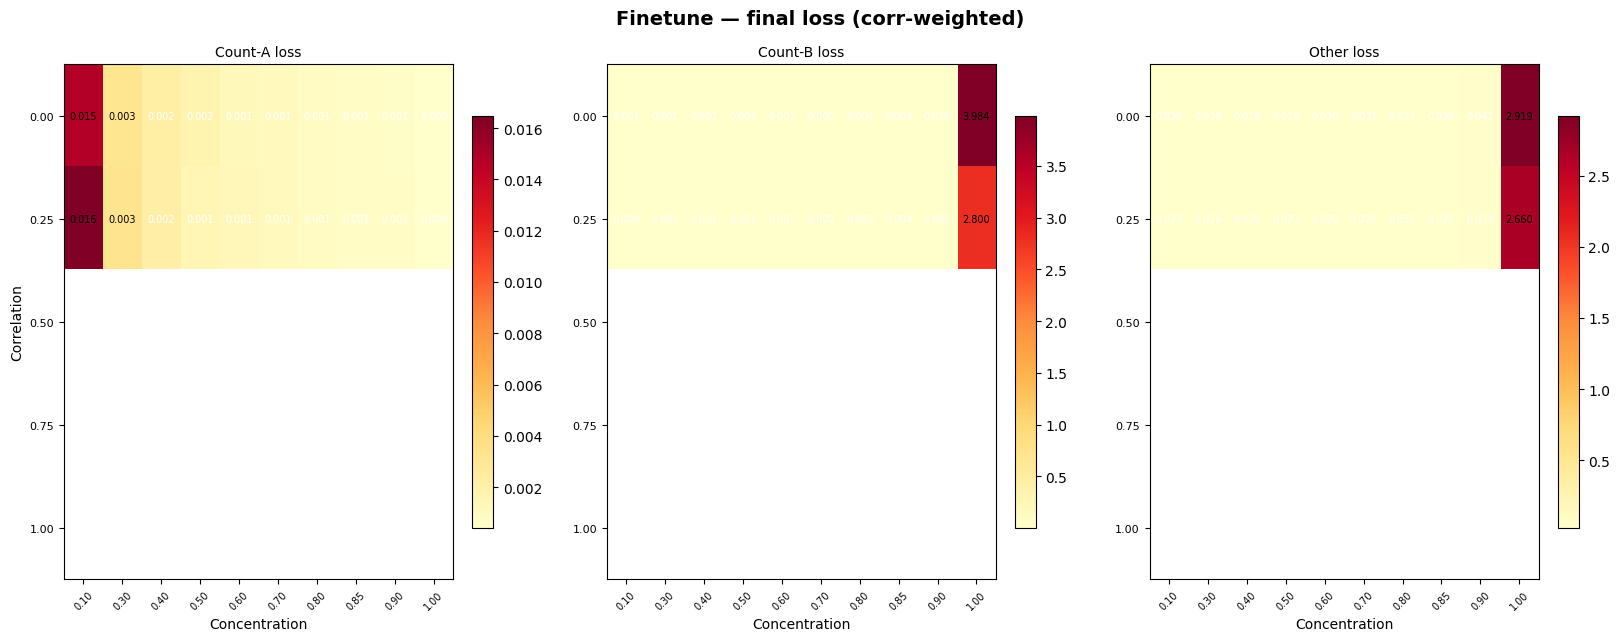

In [67]:
# --- Finetune final accuracy ---
plot_summary_heatmaps(
    phase='finetune',
    specs=[
        ('count_a_avg', 'answer_acc', 'Count-A acc', 'YlGn', True),
        ('count_b_avg', 'answer_acc', 'Count-B acc', 'YlGn', True),
        ('all_other_avg', 'answer_acc', 'Other acc', 'YlGn', True),
    ],
    suptitle='Finetune — final accuracy (corr-weighted)',
)

# --- Finetune final loss ---
plot_summary_heatmaps(
    phase='finetune',
    specs=[
        ('count_a_avg', 'loss', 'Count-A loss', 'YlOrRd', True),
        ('count_b_avg', 'loss', 'Count-B loss', 'YlOrRd', True),
        ('all_other_avg', 'loss', 'Other loss', 'YlOrRd', True),
    ],
    suptitle='Finetune — final loss (corr-weighted)',
)

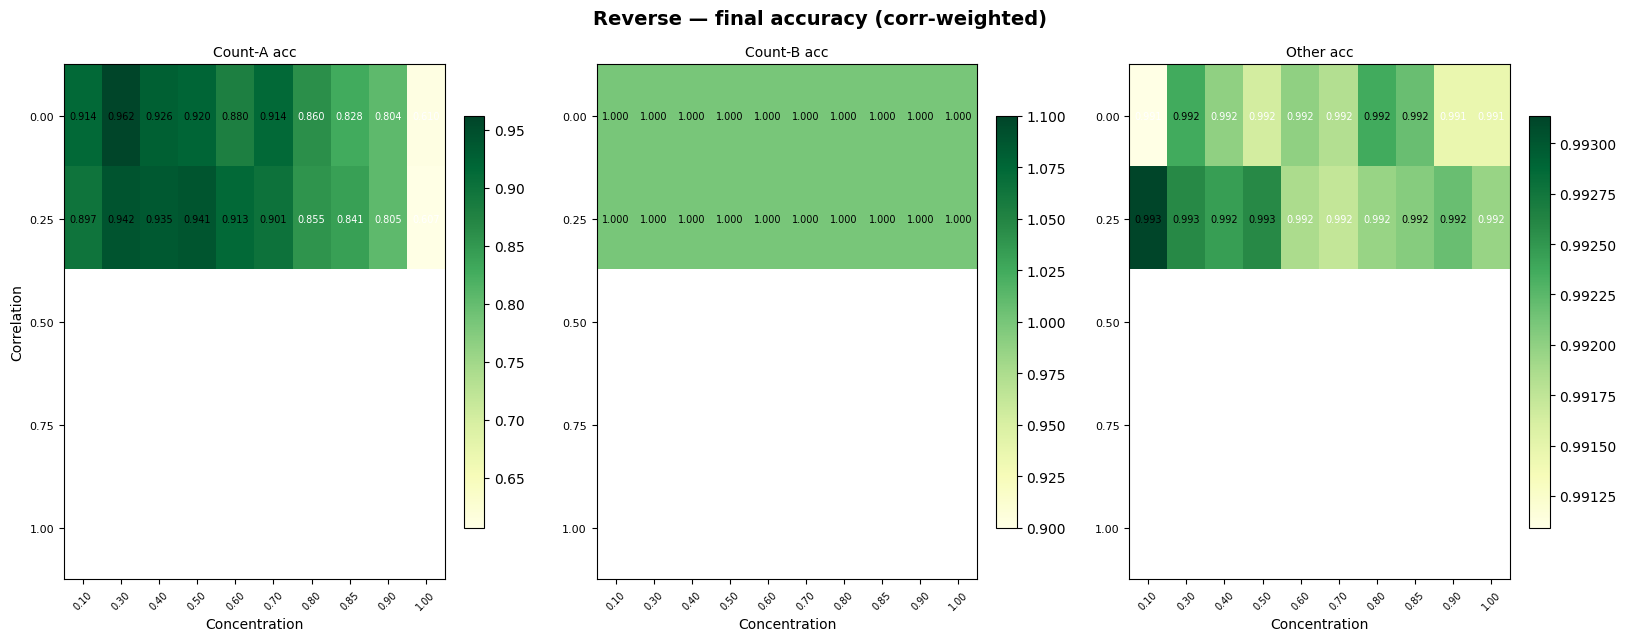

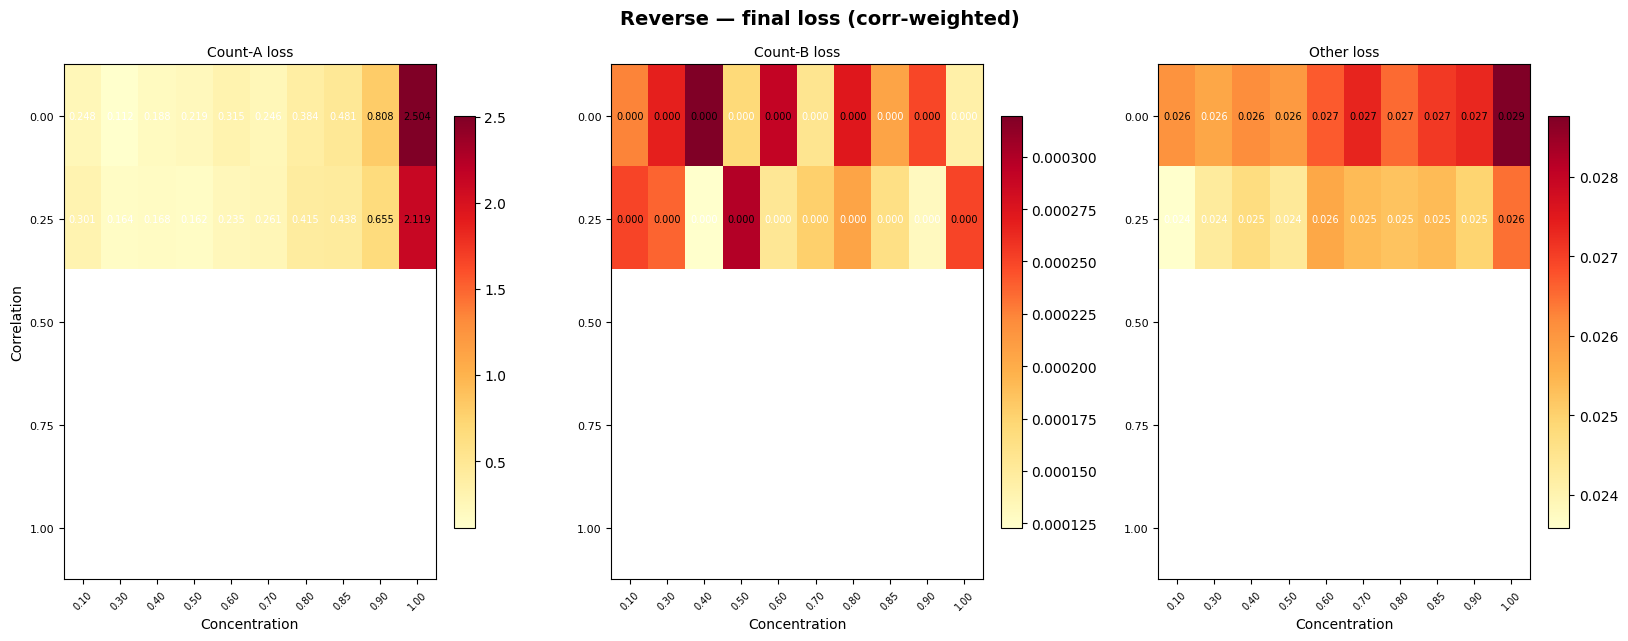

In [68]:
# --- Reverse final accuracy ---
plot_summary_heatmaps(
    phase='reverse',
    specs=[
        ('count_a_avg', 'answer_acc', 'Count-A acc', 'YlGn', True),
        ('count_b_avg', 'answer_acc', 'Count-B acc', 'YlGn', True),
        ('all_other_avg', 'answer_acc', 'Other acc', 'YlGn', True),
    ],
    suptitle='Reverse — final accuracy (corr-weighted)',
)

# --- Reverse final loss ---
plot_summary_heatmaps(
    phase='reverse',
    specs=[
        ('count_a_avg', 'loss', 'Count-A loss', 'YlOrRd', True),
        ('count_b_avg', 'loss', 'Count-B loss', 'YlOrRd', True),
        ('all_other_avg', 'loss', 'Other loss', 'YlOrRd', True),
    ],
    suptitle='Reverse — final loss (corr-weighted)',
)

## Heatmap helper

Builds a (layers × steps) heatmap for a given metric, with optional diverging colormap.

In [41]:
histories.keys()

dict_keys(['finetune_corr_0.00_conc_0.10', 'finetune_corr_0.00_conc_0.30', 'finetune_corr_0.00_conc_0.40', 'finetune_corr_0.00_conc_0.50', 'finetune_corr_0.00_conc_0.60', 'finetune_corr_0.00_conc_0.70', 'finetune_corr_0.00_conc_0.80', 'finetune_corr_0.00_conc_0.85', 'finetune_corr_0.00_conc_0.90', 'finetune_corr_0.00_conc_1.00', 'finetune_corr_0.25_conc_0.10', 'finetune_corr_0.25_conc_0.30', 'finetune_corr_0.25_conc_0.40', 'finetune_corr_0.25_conc_0.50', 'finetune_corr_0.25_conc_0.60', 'finetune_corr_0.25_conc_0.70', 'finetune_corr_0.25_conc_0.80', 'finetune_corr_0.25_conc_0.85', 'finetune_corr_0.25_conc_0.90', 'finetune_corr_0.25_conc_1.00', 'reverse_corr_0.00_conc_0.10', 'reverse_corr_0.00_conc_0.30', 'reverse_corr_0.00_conc_0.40', 'reverse_corr_0.00_conc_0.50', 'reverse_corr_0.00_conc_0.60', 'reverse_corr_0.00_conc_0.70', 'reverse_corr_0.00_conc_0.80', 'reverse_corr_0.00_conc_0.85', 'reverse_corr_0.00_conc_0.90', 'reverse_corr_0.00_conc_1.00', 'reverse_corr_0.25_conc_0.10', 'reverse

In [42]:
def extract_layer_timeseries(history, metric_path, n_layers=N_LAYERS):
    """
    Extract a (n_layers, n_steps) array from a nested history dict.
    metric_path: e.g. ('grad_count_a_vs_count_b', 'cosine_sim')
    """
    d = history
    for key in metric_path:
        d = d[key]
    # d is now {layer_idx: [val_per_step, ...]}
    n_steps = len(d[0])
    arr = np.zeros((n_layers, n_steps))
    for l in range(n_layers):
        arr[l] = d[l]
    return arr


def plot_layer_heatmap(ax, arr, steps, title='', cmap='RdBu_r', symmetric=False, vmin=None, vmax=None):
    """Plot a (layers x steps) heatmap on the given axes."""
    if symmetric:
        vabs = max(abs(arr.min()), abs(arr.max()))
        vmin, vmax = -vabs, vabs
    elif vmin is None:
        vmin, vmax = arr.min(), arr.max()
    im = ax.imshow(arr, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', origin='lower')
    ax.set_yticks(range(arr.shape[0]))
    ax.set_yticklabels([f'L{l}' for l in range(arr.shape[0])], fontsize=8)
    # Show a few step labels on x axis
    n_ticks = min(8, len(steps))
    tick_idx = np.linspace(0, len(steps)-1, n_ticks, dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([str(steps[i]) for i in tick_idx], fontsize=7, rotation=45)
    ax.set_title(title, fontsize=9)
    return im

## Stacked heatmaps: gradient metrics over training

For each model (corr, conc), show stacked heatmaps (layers × steps) for:
1. Cosine similarity (count_a vs count_b)
2. Dot product (count_a vs count_b)
3. Layerwise drift
4. Count-A accuracy (weighted avg) — for context
5. Count-B accuracy (weighted avg) — for context

In [43]:
def plot_stacked_heatmaps_for_model(ft_key, rv_key, corr, conc):
    """Plot stacked heatmaps for a single model's finetune + reverse trajectory."""
    ft_h = histories.get(ft_key)
    rv_h = histories.get(rv_key)
    if ft_h is None or rv_h is None:
        return
    if 'grad_count_a_vs_count_b' not in ft_h:
        return

    # Combine finetune and reverse steps
    ft_steps = ft_h['steps']
    ft_last = ft_steps[-1]
    rv_steps = [ft_last + s for s in rv_h['steps']]
    all_steps = ft_steps + rv_steps
    boundary_idx = len(ft_steps)

    metric_specs = []

    # 1. Cosine sim: count_a vs count_b
    if 'grad_count_a_vs_count_b' in ft_h and 'grad_count_a_vs_count_b' in rv_h:
        ft_cos = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'cosine_sim'))
        rv_cos = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'cosine_sim'))
        metric_specs.append(('Cosine sim (A vs B)', np.hstack([ft_cos, rv_cos]), 'RdBu_r', True))

    # 2. Dot product: count_a vs count_b
    if 'grad_count_a_vs_count_b' in ft_h and 'grad_count_a_vs_count_b' in rv_h:
        ft_dot = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'dot_product'))
        rv_dot = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'dot_product'))
        metric_specs.append(('Dot product (A vs B)', np.hstack([ft_dot, rv_dot]), 'RdBu_r', True))

    # 3. Cosine sim: count_a vs all_other
    if 'grad_count_a_vs_all_other' in ft_h and 'grad_count_a_vs_all_other' in rv_h:
        ft_cos2 = extract_layer_timeseries(ft_h, ('grad_count_a_vs_all_other', 'cosine_sim'))
        rv_cos2 = extract_layer_timeseries(rv_h, ('grad_count_a_vs_all_other', 'cosine_sim'))
        metric_specs.append(('Cosine sim (A vs Other)', np.hstack([ft_cos2, rv_cos2]), 'RdBu_r', True))

    # 4. Layerwise drift
    if 'layerwise_drift' in ft_h and 'layerwise_drift' in rv_h:
        ft_drift = extract_layer_timeseries(ft_h, ('layerwise_drift',))
        rv_drift = extract_layer_timeseries(rv_h, ('layerwise_drift',))
        metric_specs.append(('Layerwise drift', np.hstack([ft_drift, rv_drift]), 'hot', False))

    # 5. Gradient norms (count_a and count_b)
    if 'grad_count_a_vs_count_b' in ft_h and 'grad_count_a_vs_count_b' in rv_h:
        ft_na = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'norm_a'))
        rv_na = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'norm_a'))
        metric_specs.append(('||∇L_A|| (count_a)', np.hstack([ft_na, rv_na]), 'YlOrRd', False))

        ft_nb = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'norm_b'))
        rv_nb = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'norm_b'))
        metric_specs.append(('||∇L_B|| (count_b)', np.hstack([ft_nb, rv_nb]), 'YlOrRd', False))

    if not metric_specs:
        return

    n_metrics = len(metric_specs)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(14, 2.5 * n_metrics), sharex=True)
    if n_metrics == 1:
        axes = [axes]
    fig.suptitle(f'corr={corr:.2f}  conc={conc:.2f} — finetune → reverse',
                 fontsize=13, fontweight='bold')

    for ax, (title, arr, cmap, symmetric) in zip(axes, metric_specs):
        im = plot_layer_heatmap(ax, arr, all_steps, title=title, cmap=cmap, symmetric=symmetric)
        ax.axvline(boundary_idx - 0.5, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
        fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

    axes[-1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()

### All models — individual stacked heatmaps

In [59]:
# for corr in CORRS:
#     for conc in CONCS:
#         ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
#         rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'
#         plot_stacked_heatmaps_for_model(ft_key, rv_key, corr, conc)

## Summary grids: one metric across all models

For a single metric, show a grid of heatmaps (rows = correlations, cols = concentrations).
Each cell is a (layers × steps) heatmap.

In [45]:
def plot_metric_grid(metric_path, title, cmap='RdBu_r', symmetric=False, phase='both', same_vmax=False):
    """
    Grid of heatmaps: rows=correlations, cols=concentrations.
    phase: 'finetune', 'reverse', or 'both' (combined).
    """
    fig, axes = plt.subplots(len(CORRS), len(CONCS), figsize=(3.5 * len(CONCS), 2.5 * len(CORRS)))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    # First pass: find global vmin/vmax
    all_vals = []
    for corr in CORRS:
        for conc in CONCS:
            for prefix in ['finetune', 'reverse']:
                key = f'{prefix}_corr_{corr:.2f}_conc_{conc:.2f}'
                if key in histories and metric_path[0] in histories[key]:
                    try:
                        arr = extract_layer_timeseries(histories[key], metric_path)
                        all_vals.append(arr)
                    except (KeyError, TypeError):
                        pass
    if not all_vals:
        print(f'No data found for {metric_path}')
        plt.close(fig)
        return
    all_concat = np.concatenate([a.flatten() for a in all_vals])
    if symmetric:
        vabs = max(abs(all_concat.min()), abs(all_concat.max()))
        gvmin, gvmax = -vabs, vabs
    else:
        gvmin, gvmax = all_concat.min(), all_concat.max()

    for row, corr in enumerate(CORRS):
        for col, conc in enumerate(CONCS):
            ax = axes[row, col]
            ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
            rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'

            arrs = []
            steps_list = []
            boundary_idx = None

            if phase in ('finetune', 'both') and ft_key in histories:
                try:
                    ft_arr = extract_layer_timeseries(histories[ft_key], metric_path)
                    arrs.append(ft_arr)
                    steps_list.extend(histories[ft_key]['steps'])
                    boundary_idx = ft_arr.shape[1]
                except (KeyError, TypeError):
                    pass

            if phase in ('reverse', 'both') and rv_key in histories:
                try:
                    rv_arr = extract_layer_timeseries(histories[rv_key], metric_path)
                    arrs.append(rv_arr)
                    if steps_list:
                        offset = steps_list[-1]
                        steps_list.extend([offset + s for s in histories[rv_key]['steps']])
                    else:
                        steps_list.extend(histories[rv_key]['steps'])
                except (KeyError, TypeError):
                    pass

            if not arrs:
                ax.set_visible(False)
                continue

            combined = np.hstack(arrs)
            if same_vmax:
                im = ax.imshow(combined, aspect='auto', cmap=cmap, vmin=gvmin, vmax=gvmax,
                            interpolation='nearest', origin='lower')
            else:
                #keep 0 in the middle
                vmax = max(abs(combined.min()), abs(combined.max()))
                vmin = -vmax if symmetric else combined.min()
                im = ax.imshow(combined, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                            interpolation='nearest', origin='lower')
            if boundary_idx is not None and phase == 'both' and len(arrs) == 2:
                ax.axvline(boundary_idx - 0.5, color='white', linestyle='--', linewidth=1, alpha=0.8)

            ax.set_yticks(range(N_LAYERS))
            ax.set_yticklabels([f'L{l}' for l in range(N_LAYERS)], fontsize=6)
            n_ticks = min(5, len(steps_list))
            tick_idx = np.linspace(0, len(steps_list)-1, n_ticks, dtype=int)
            ax.set_xticks(tick_idx)
            ax.set_xticklabels([str(steps_list[i]) for i in tick_idx], fontsize=6, rotation=45)

            if row == 0:
                ax.set_title(f'conc={conc:.2f}', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'corr={corr:.2f}', fontsize=9)

    fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
    plt.tight_layout()
    plt.show()

### Cosine similarity: count_a vs count_b

In [57]:
# plot_metric_grid(
#     metric_path=('grad_count_a_vs_count_b', 'cosine_sim'),
#     title='Cosine similarity: ∇count_a vs ∇count_b (per layer over training)',
#     cmap='RdBu_r', symmetric=True, phase='both',
# )

### Dot product: count_a vs count_b

/tmp/ipykernel_19063/3533648590.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


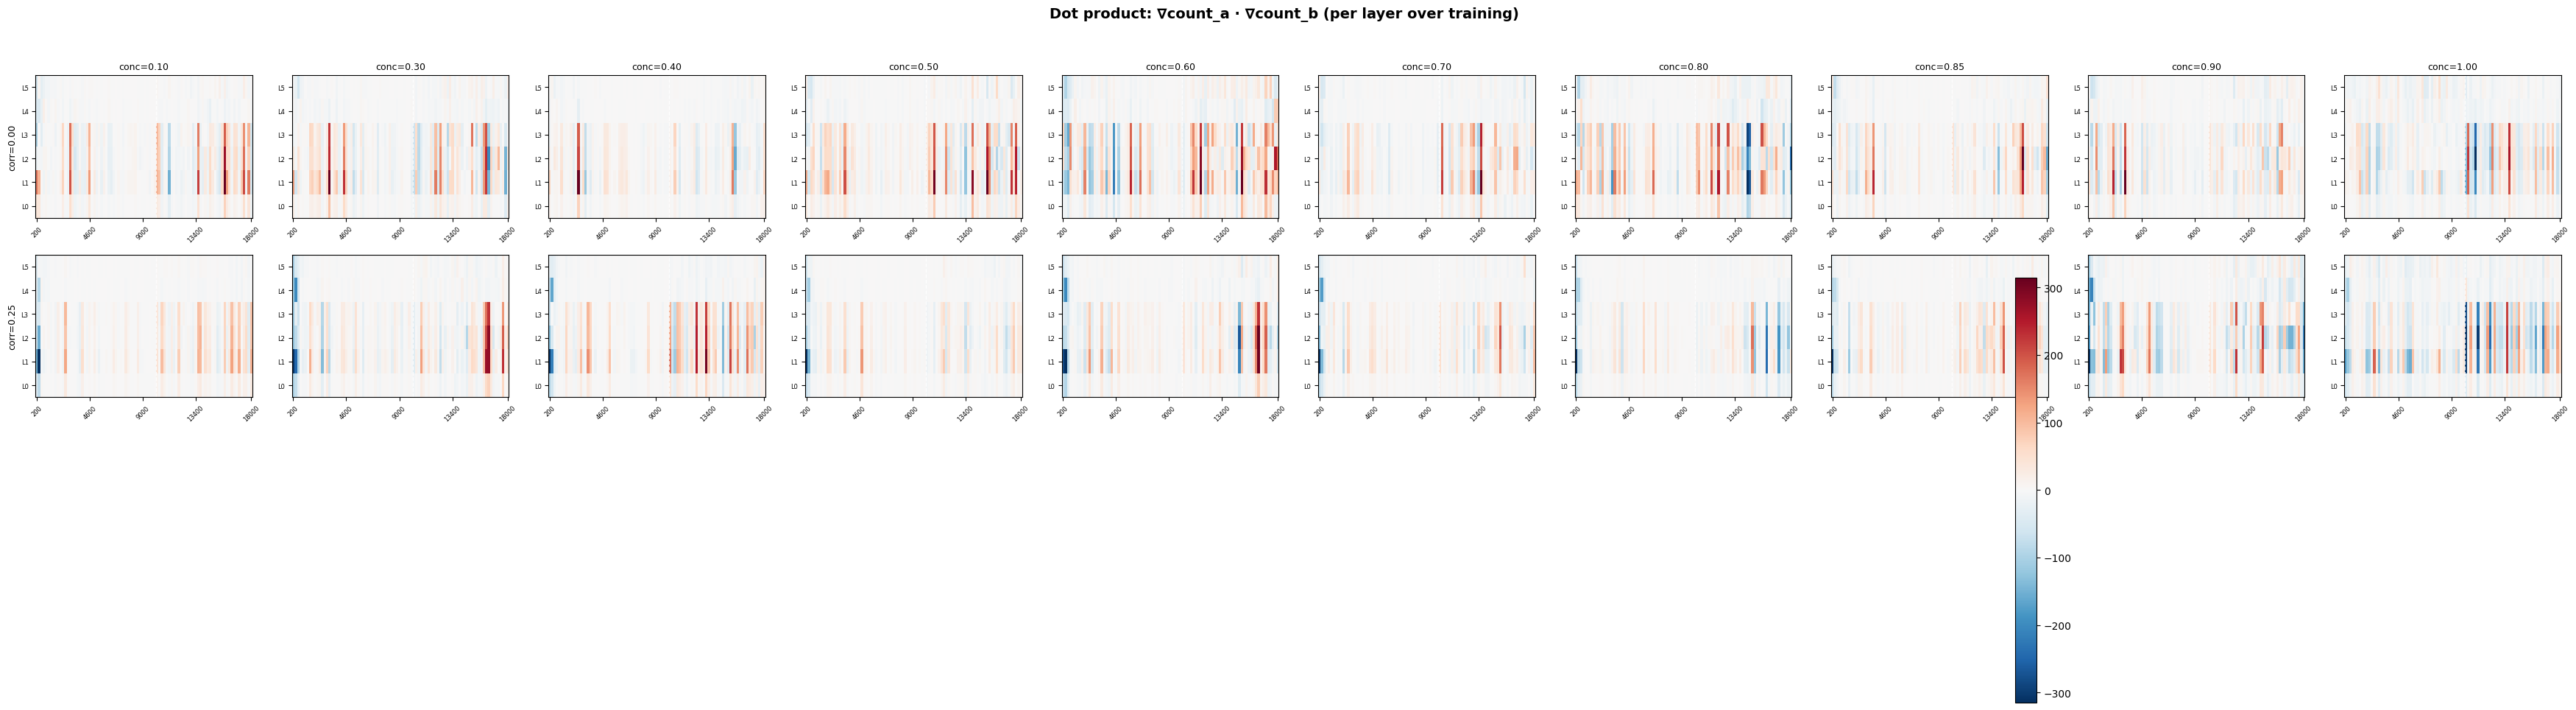

In [47]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'dot_product'),
    title='Dot product: ∇count_a · ∇count_b (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Cosine similarity: count_a vs all_other

/tmp/ipykernel_19063/3533648590.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


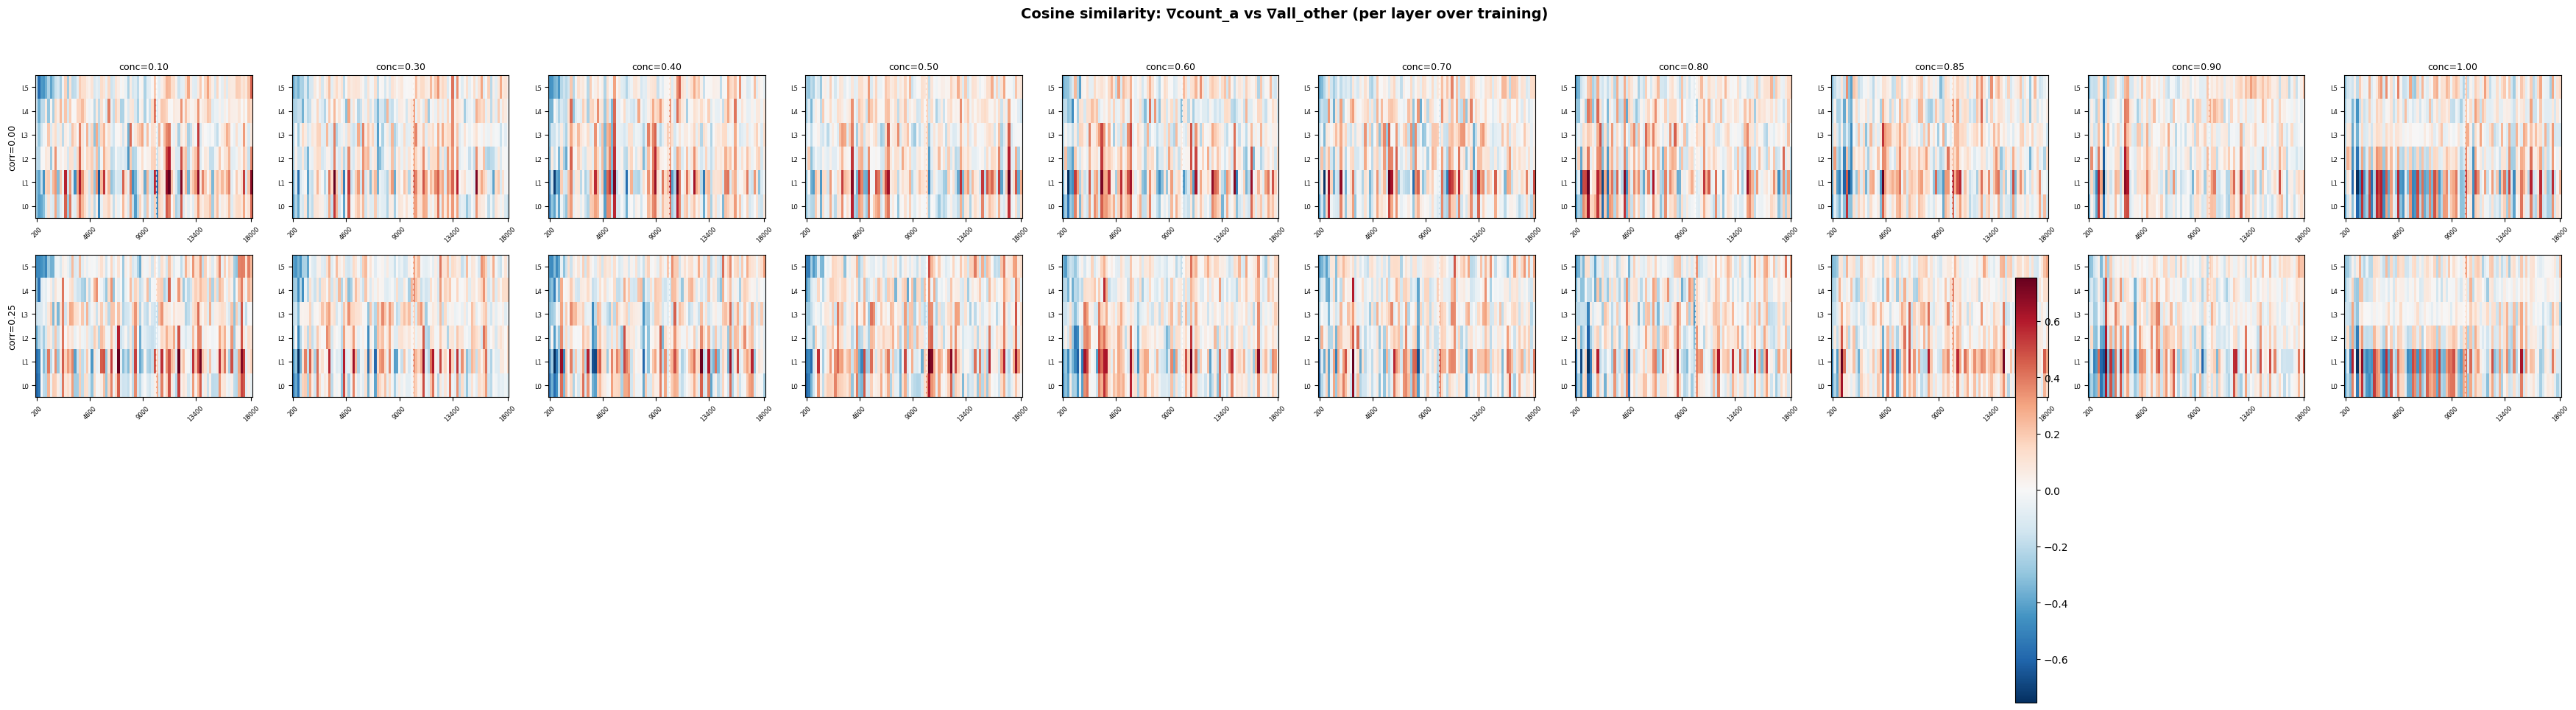

In [48]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_all_other', 'cosine_sim'),
    title='Cosine similarity: ∇count_a vs ∇all_other (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Dot product: count_a vs all_other

/tmp/ipykernel_19063/3533648590.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


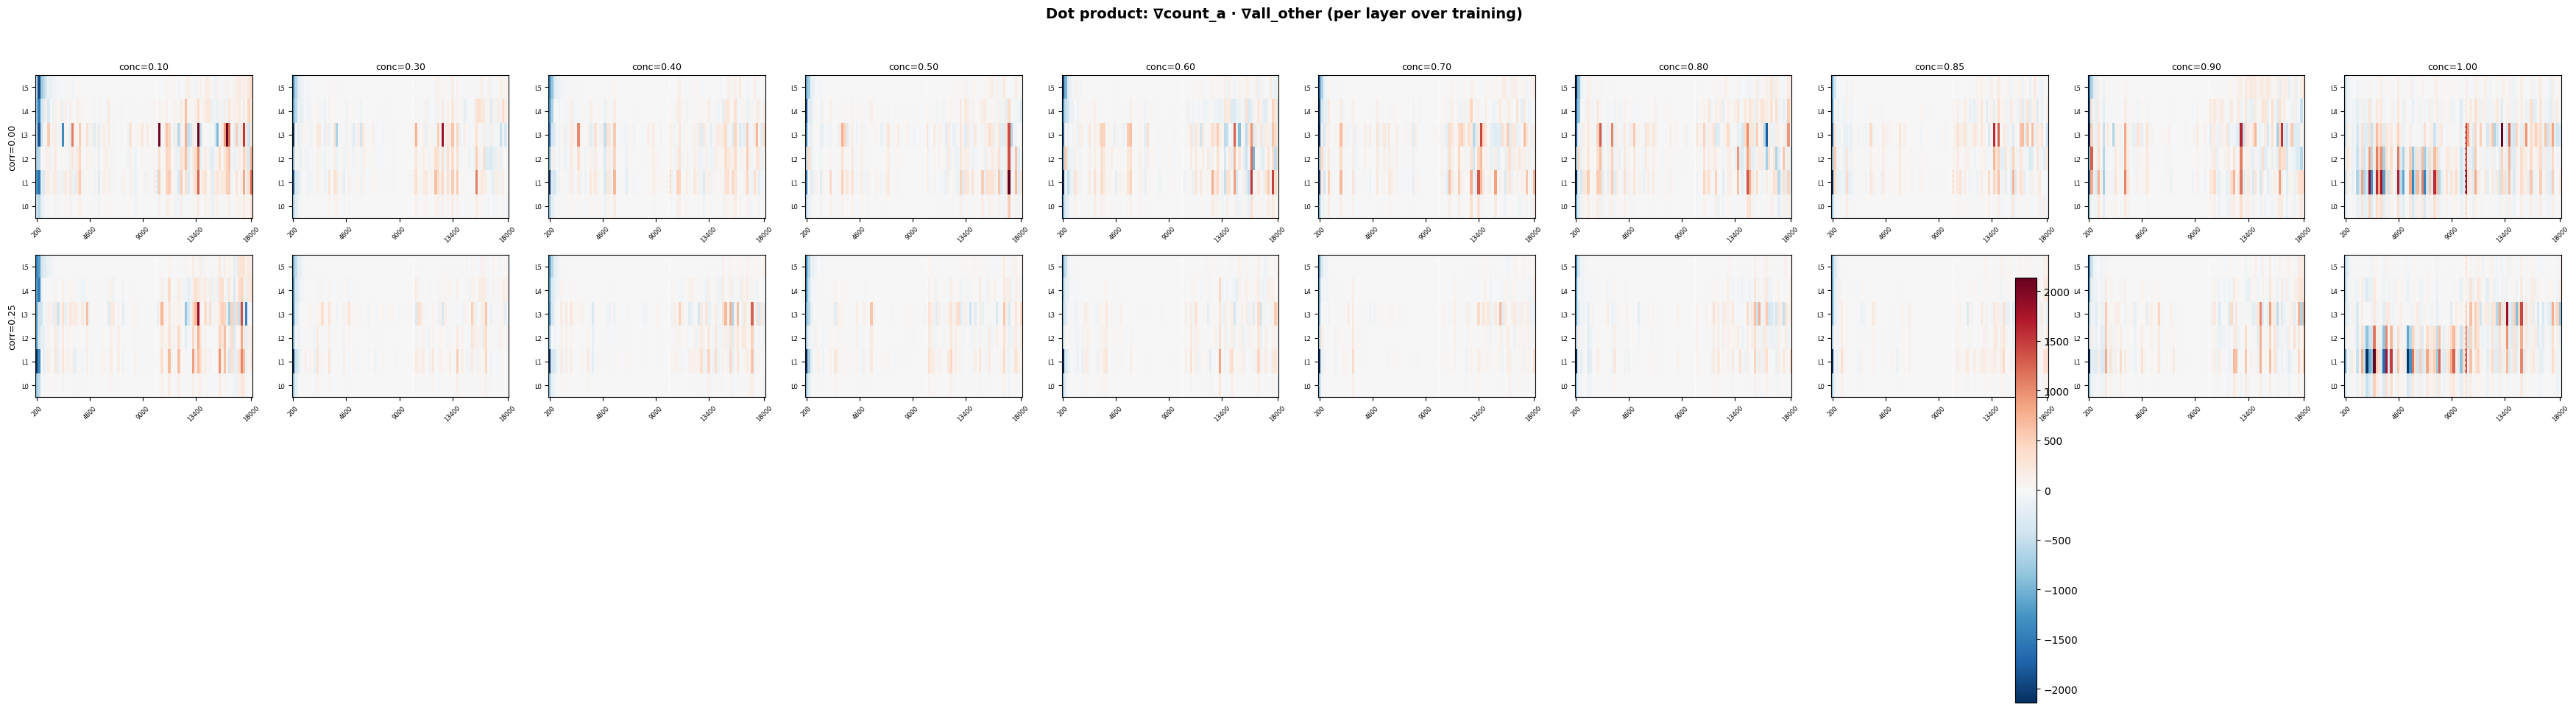

In [49]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_all_other', 'dot_product'),
    title='Dot product: ∇count_a · ∇all_other (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Layerwise drift (weight change per eval step)

/tmp/ipykernel_19063/3533648590.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


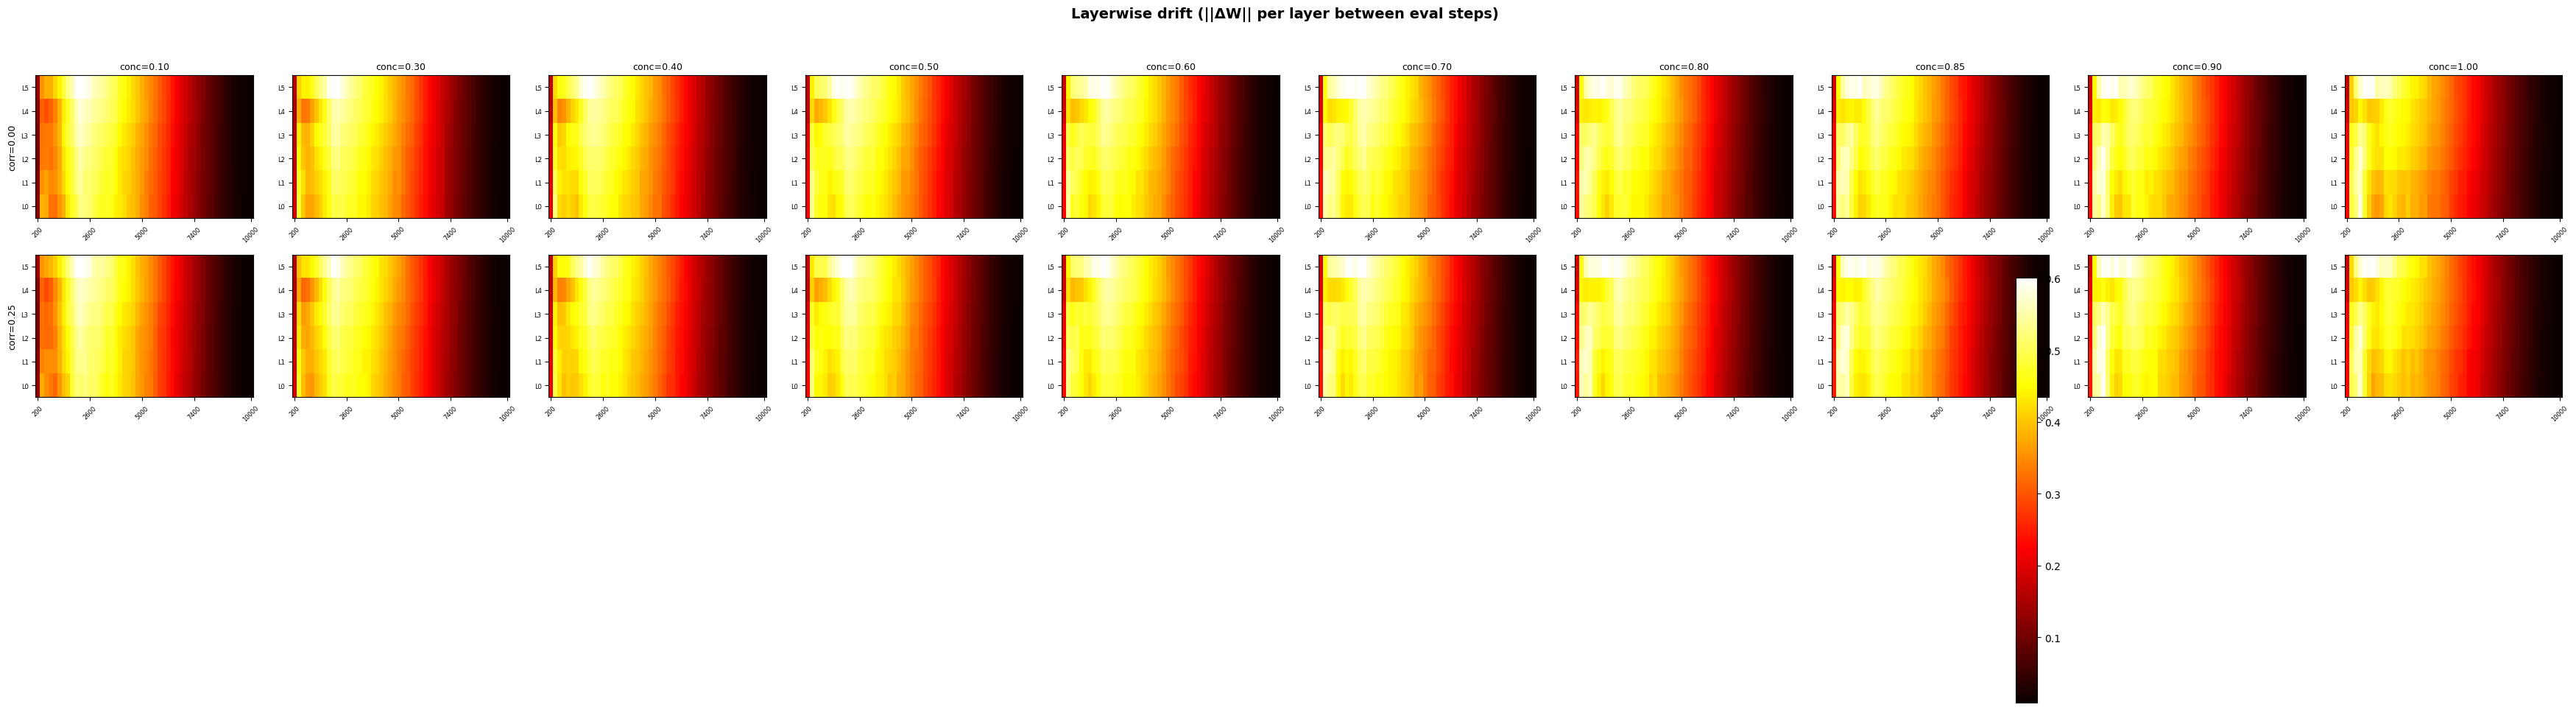

In [50]:
plot_metric_grid(
    metric_path=('layerwise_drift',),
    title='Layerwise drift (||ΔW|| per layer between eval steps)',
    cmap='hot', symmetric=False, phase='finetune', same_vmax=False
)

### Gradient norms

/tmp/ipykernel_19063/3533648590.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


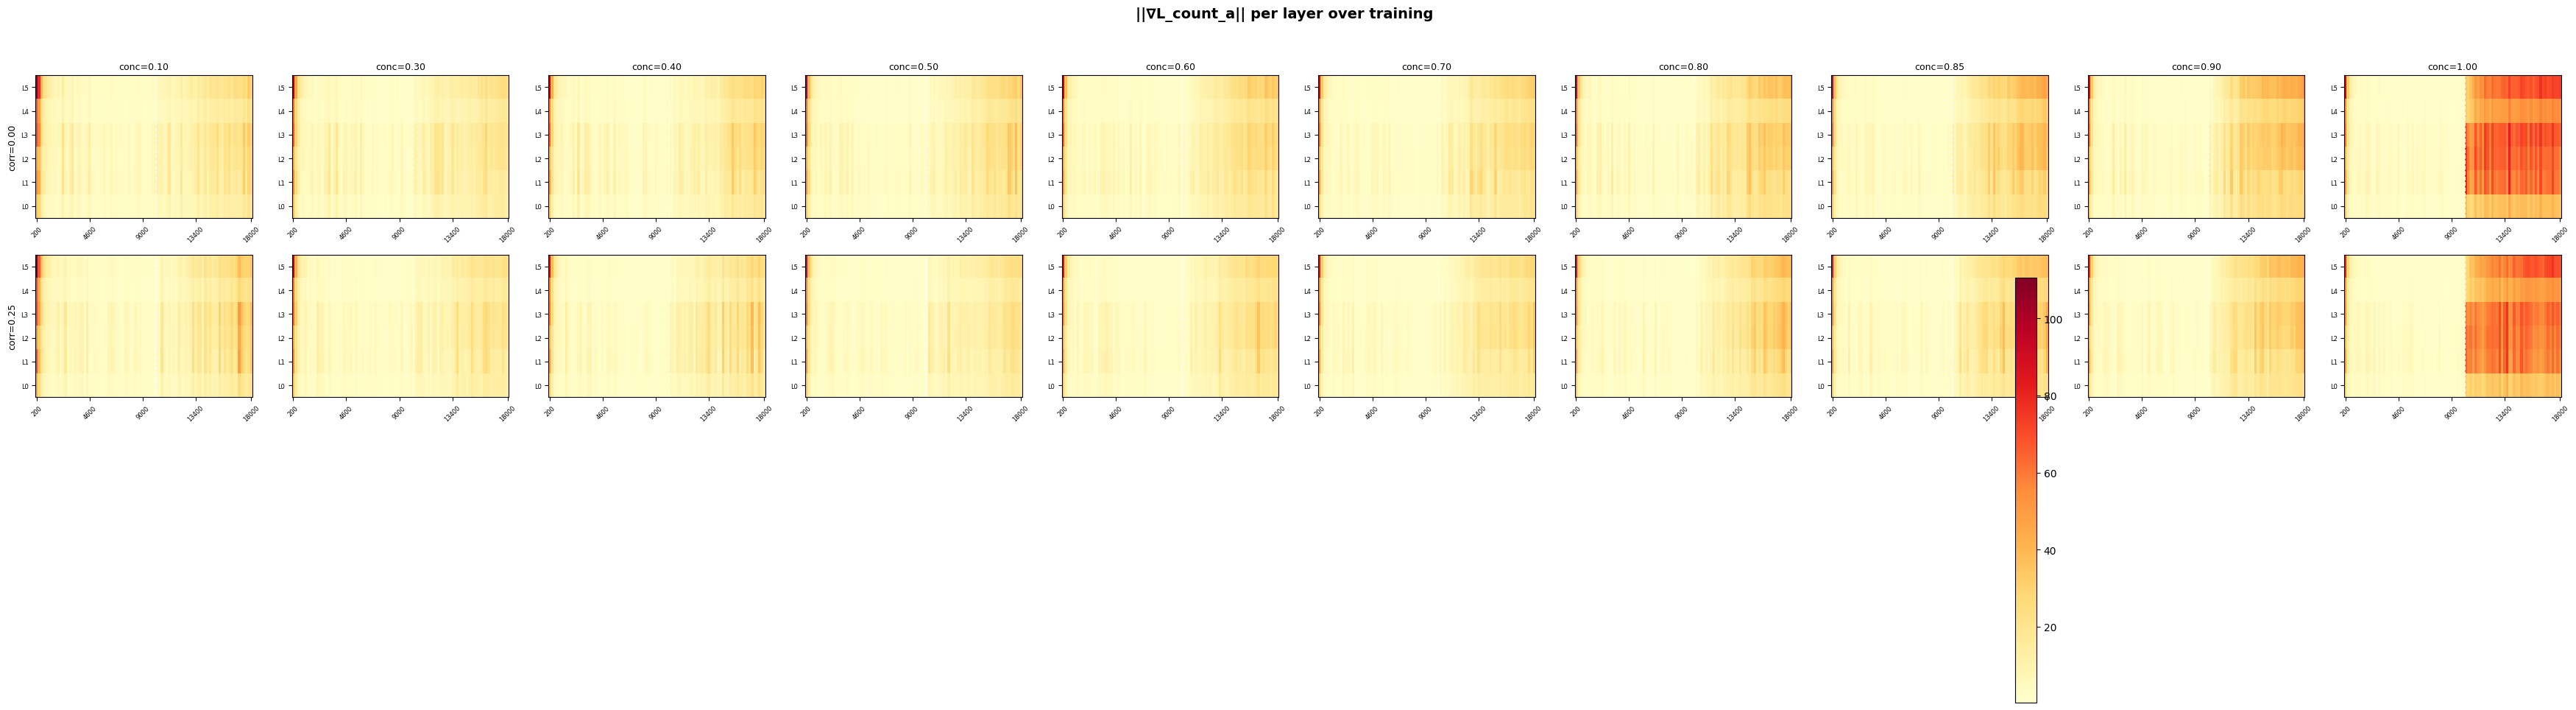

/tmp/ipykernel_19063/3533648590.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


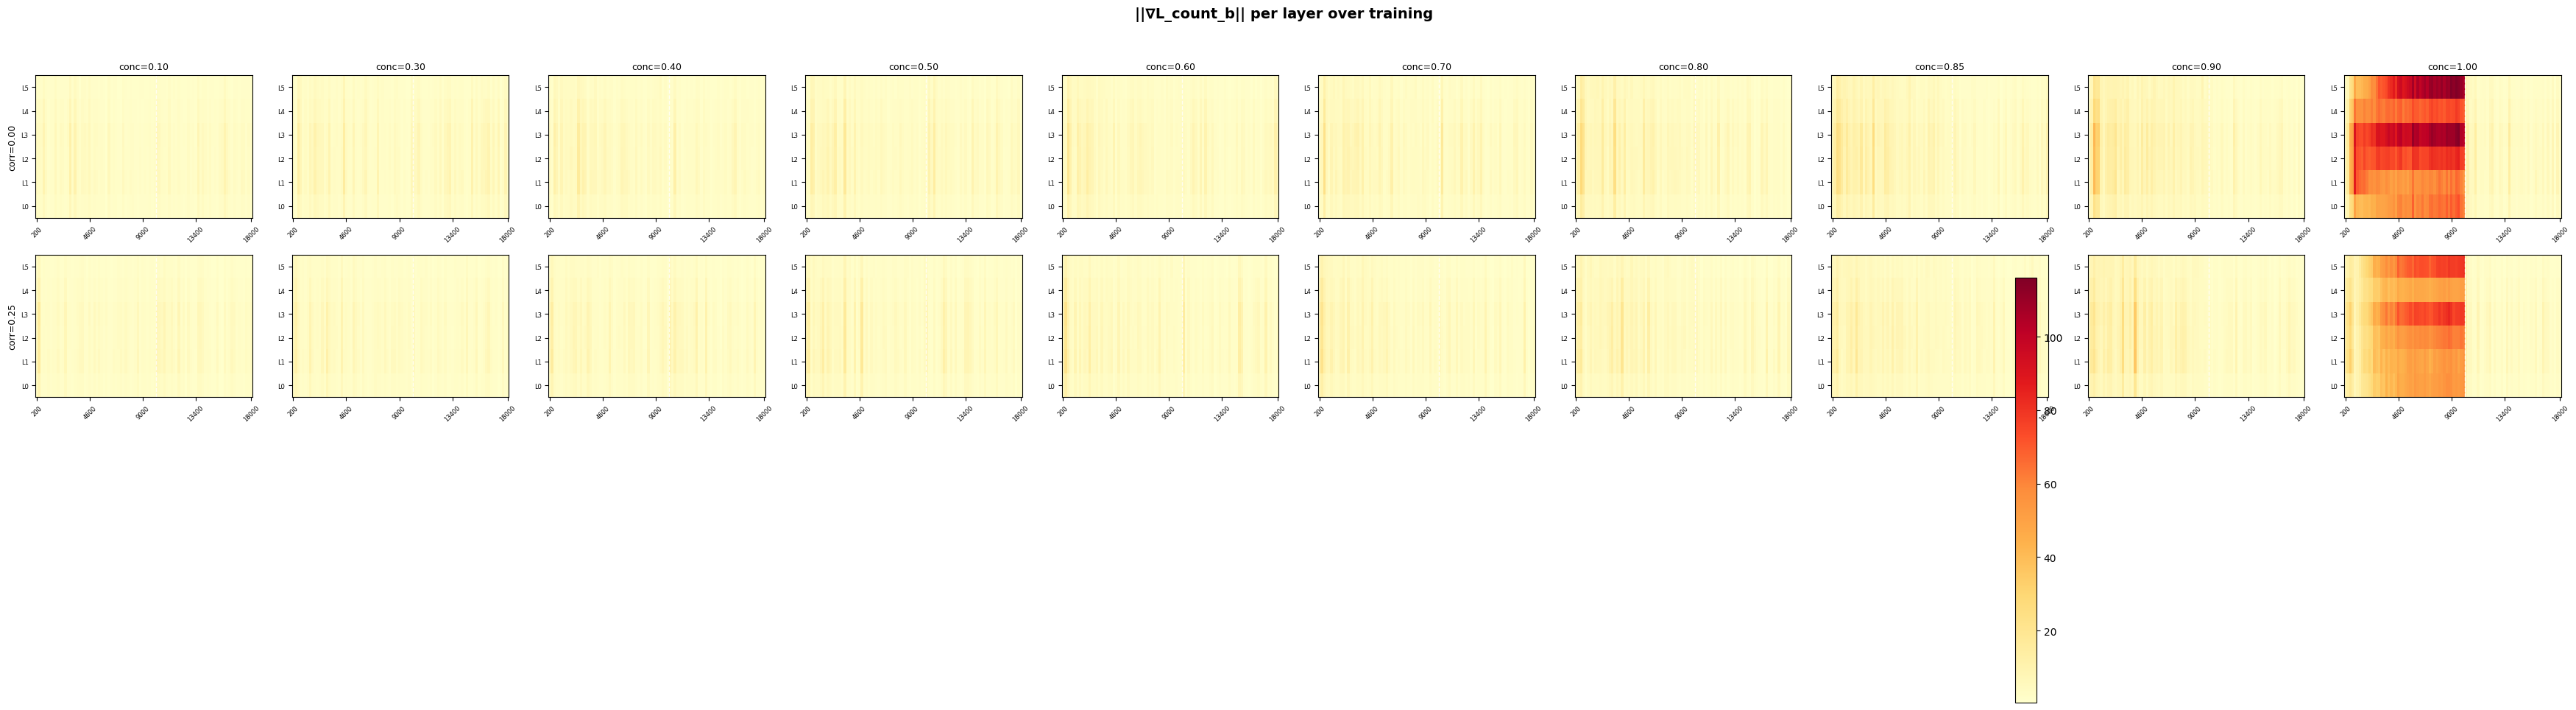

In [51]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'norm_a'),
    title='||∇L_count_a|| per layer over training',
    cmap='YlOrRd', symmetric=False, phase='both', same_vmax=True
)

plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'norm_b'),
    title='||∇L_count_b|| per layer over training',
    cmap='YlOrRd', symmetric=False, phase='both', same_vmax=True
)

## Line plots: metric averaged across layers

Sometimes easier to read than heatmaps — shows the layer-averaged metric over training steps.

In [52]:
CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

def plot_metric_lines(metric_path, title, ylabel, per_layer=False):
    """
    Line plots: one column per correlation, all concentrations overlaid.
    If per_layer=False: shows layer-averaged value over steps.
    If per_layer=True: shows one row per layer.
    """
    n_rows = N_LAYERS if per_layer else 1
    fig, axes = plt.subplots(n_rows, len(CORRS), figsize=(22, 3.5 * n_rows), sharey='row')
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for col, corr in enumerate(CORRS):
        for conc, color in zip(CONCS, CONC_COLORS):
            ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
            rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'

            arrs = []
            steps_list = []
            boundary = None

            for prefix, hkey in [('finetune', ft_key), ('reverse', rv_key)]:
                if hkey not in histories:
                    continue
                try:
                    arr = extract_layer_timeseries(histories[hkey], metric_path)
                    arrs.append(arr)
                    h_steps = histories[hkey]['steps']
                    if steps_list:
                        offset = steps_list[-1]
                        boundary = offset
                        steps_list.extend([offset + s for s in h_steps])
                    else:
                        steps_list.extend(h_steps)
                except (KeyError, TypeError):
                    pass

            if not arrs:
                continue
            combined = np.hstack(arrs)  # (n_layers, n_steps)

            if per_layer:
                for l in range(N_LAYERS):
                    ax = axes[l, col]
                    ax.plot(steps_list, combined[l], color=color, linewidth=1.2,
                            label=f'conc={conc:.1f}')
                    if boundary is not None:
                        ax.axvline(boundary, color='black', linestyle='--', alpha=0.4)
                    ax.axhline(0, color='grey', linestyle='-', alpha=0.2)
                    ax.grid(True, alpha=0.2)
                    if l == 0:
                        ax.set_title(f'corr={corr:.2f}', fontsize=10)
                    if col == 0:
                        ax.set_ylabel(f'Layer {l}')
                    if l == N_LAYERS - 1:
                        ax.set_xlabel('Step')
            else:
                ax = axes[0, col]
                mean_vals = combined.mean(axis=0)
                ax.plot(steps_list, mean_vals, color=color, linewidth=1.5,
                        label=f'conc={conc:.1f}')
                if boundary is not None:
                    ax.axvline(boundary, color='black', linestyle='--', alpha=0.4)
                ax.axhline(0, color='grey', linestyle='-', alpha=0.2)
                ax.grid(True, alpha=0.2)
                ax.set_title(f'corr={corr:.2f}', fontsize=10)
                if col == 0:
                    ax.set_ylabel(ylabel)
                ax.set_xlabel('Step')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(CONCS),
               fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()

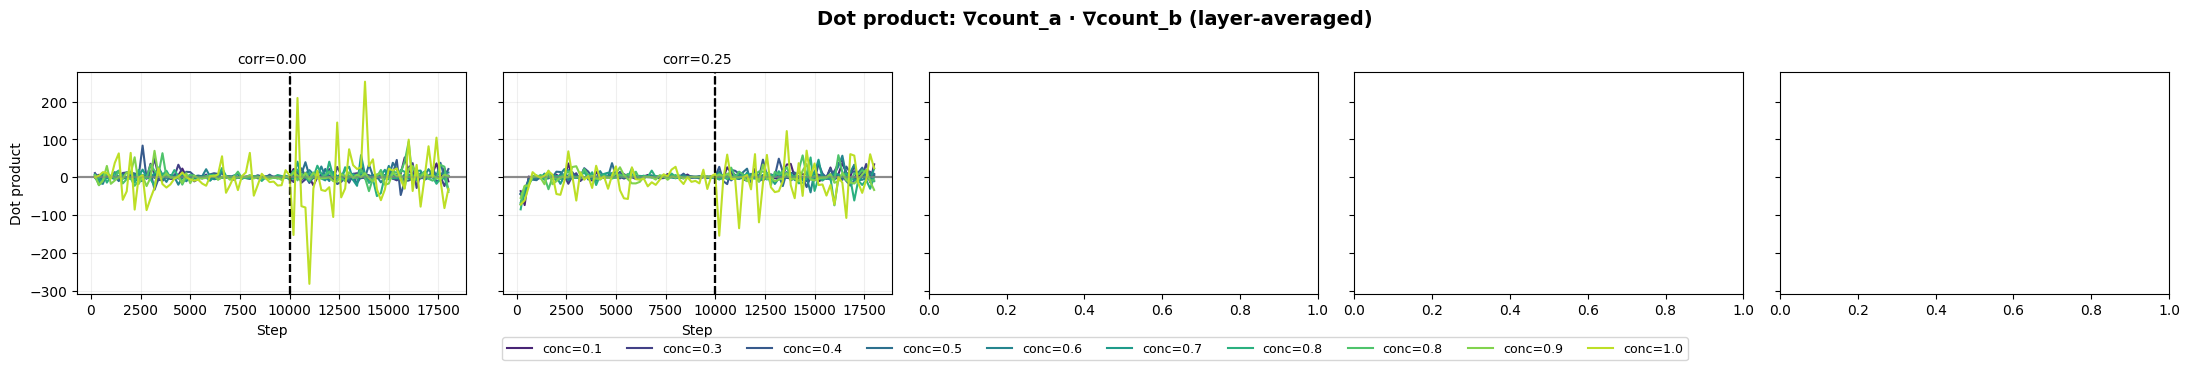

In [53]:
plot_metric_lines(
    metric_path=('grad_count_a_vs_count_b', 'dot_product'),
    title='Dot product: ∇count_a · ∇count_b (layer-averaged)',
    ylabel='Dot product',
)

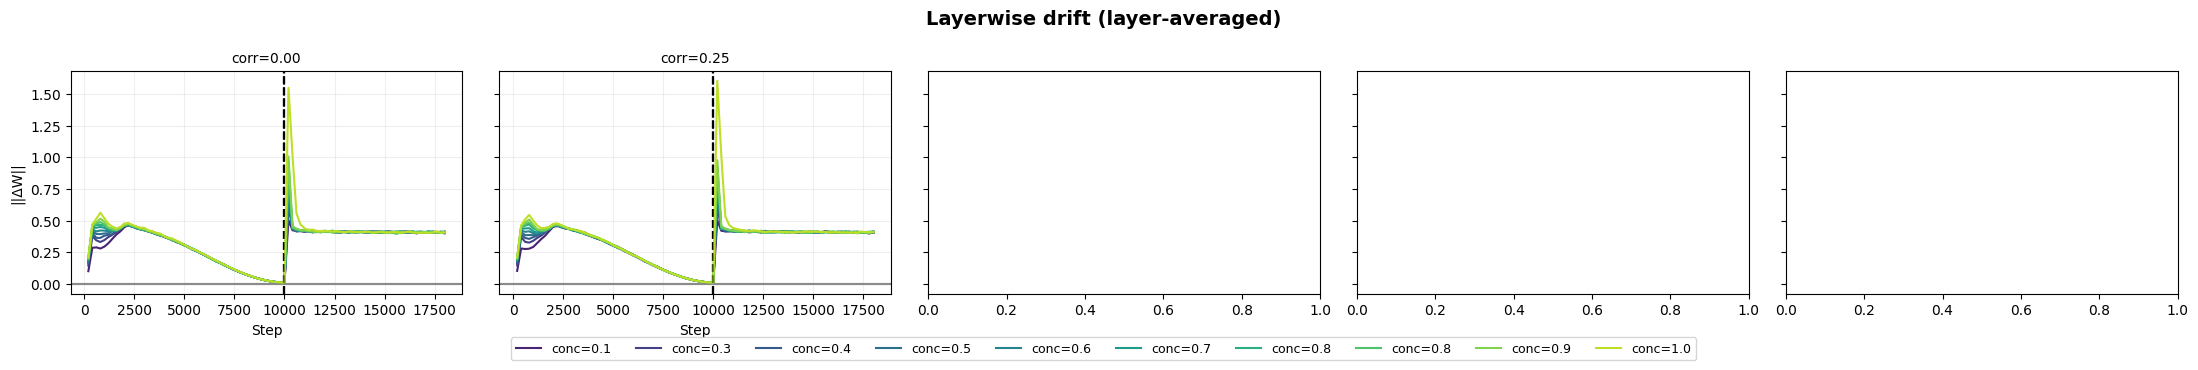

In [54]:
plot_metric_lines(
    metric_path=('layerwise_drift',),
    title='Layerwise drift (layer-averaged)',
    ylabel='||ΔW||',
)

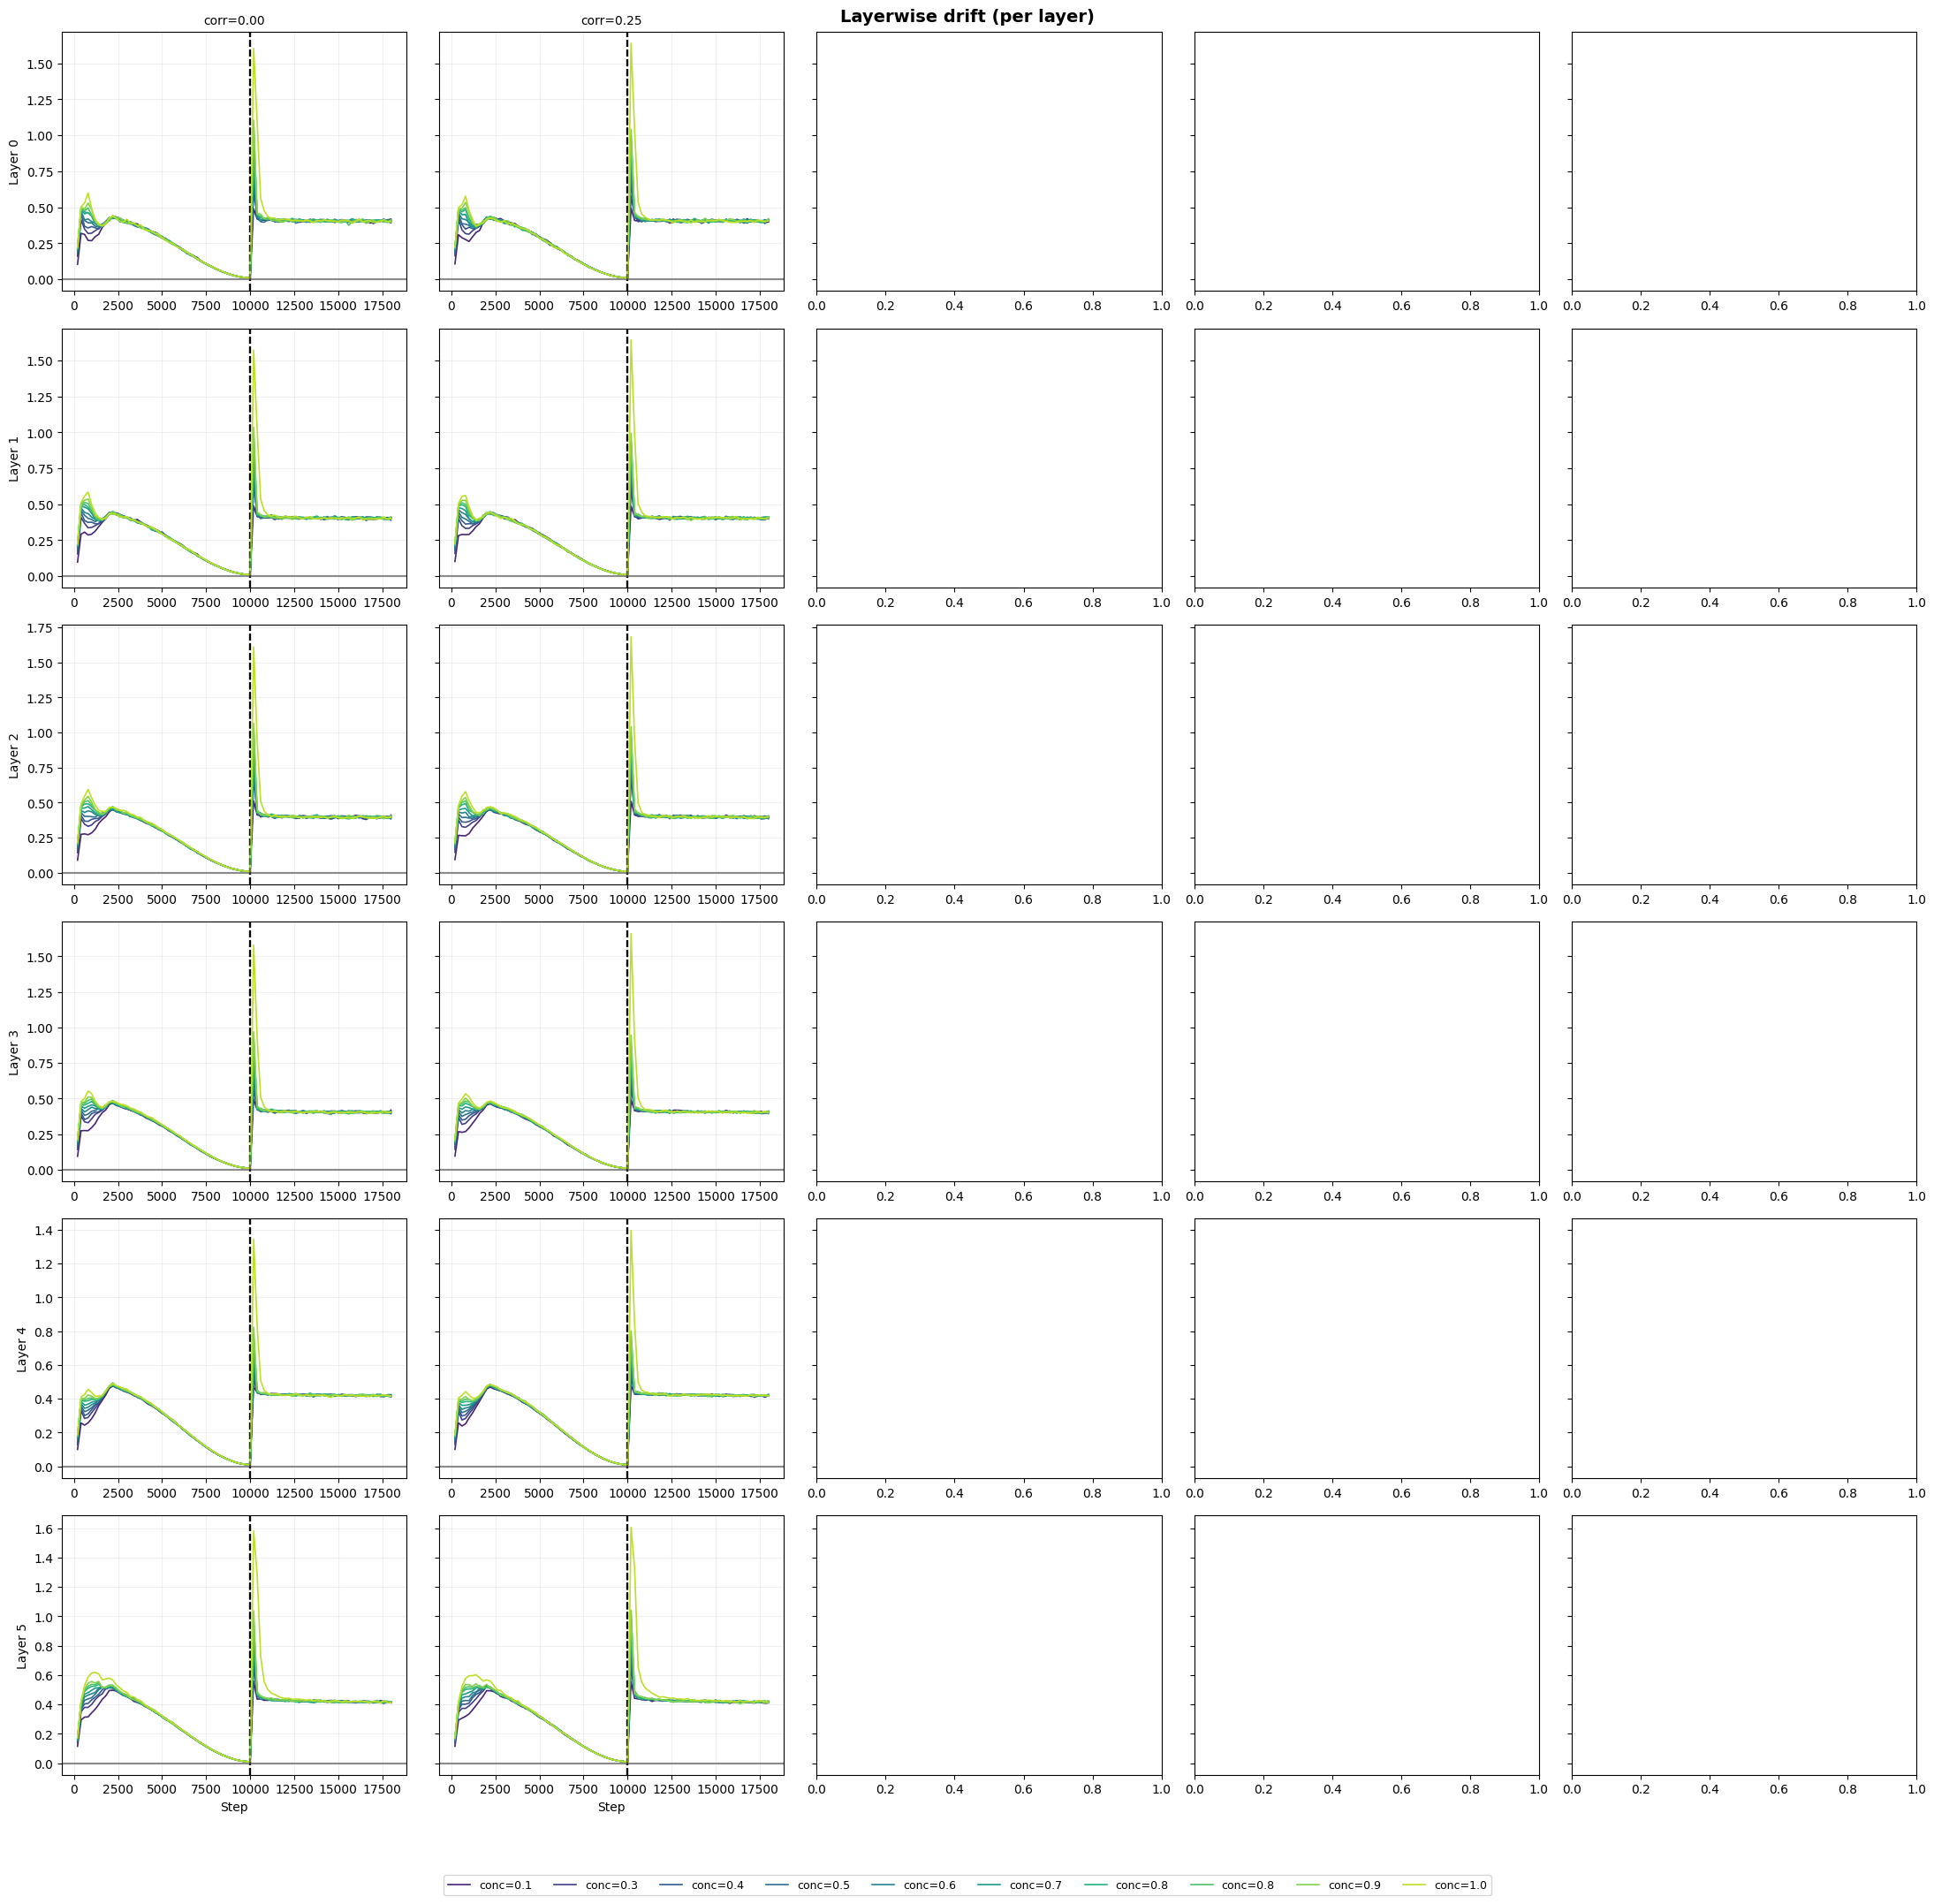

In [55]:
plot_metric_lines(
    metric_path=('layerwise_drift',),
    title='Layerwise drift (per layer)',
    ylabel='||ΔW||',
    per_layer=True,
)